<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
# !pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

# **Loading the dataset**

In [ ]:
# If loading file from Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path_to_folder = "" # replace with path to folder here
file_name = "EasyVisa.csv"

df = pd.read_csv(path_to_folder + file_name)

In [ ]:
if 'df_original' not in globals():
  df_original = df.copy()

# Helper Functions

In [ ]:
def col_countplot_hue(df, col, hue_col):
  plt.figure(figsize=(10, 6))
  sns.countplot(x=col, hue=hue_col, data=df)
  plt.title(f'Distribution of {col} by {hue_col}')
  plt.xlabel(col)

In [ ]:
def counts_case_status(df, col):
  return df.groupby([col, 'case_status']).size()

In [ ]:
def relative_freq_case_status(df, col, percent=True):
  multiplier = 1
  round_place = 1
  if (percent == True):
    multiplier = 100
    round_place = 3
  frequencies = df.groupby([col, 'case_status']).size() / df.groupby([col]).size()
  # get the frequencies to 2 decimal places
  frequencies = frequencies.apply(lambda x: round(x, round_place))
  return frequencies * multiplier

# **Overview of the Dataset**

* Observations

* Sanity checks

In [ ]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
print(df.shape)

(25480, 12)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB
None


In [ ]:
print(df.isnull().sum())

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


> Here, we see no missing values

In [ ]:
print(df.describe())

       no_of_employees   yr_of_estab  prevailing_wage
count     25480.000000  25480.000000     25480.000000
mean       5667.043210   1979.409929     74455.814592
std       22877.928848     42.366929     52815.942327
min         -26.000000   1800.000000         2.136700
25%        1022.000000   1976.000000     34015.480000
50%        2109.000000   1997.000000     70308.210000
75%        3504.000000   2005.000000    107735.512500
max      602069.000000   2016.000000    319210.270000


# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical columns: {numerical_cols}\n")
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols.drop('case_id')
print(f"Categorical columns: {categorical_cols}")

Numerical columns: Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

Categorical columns: Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')


## Univariate Analysis

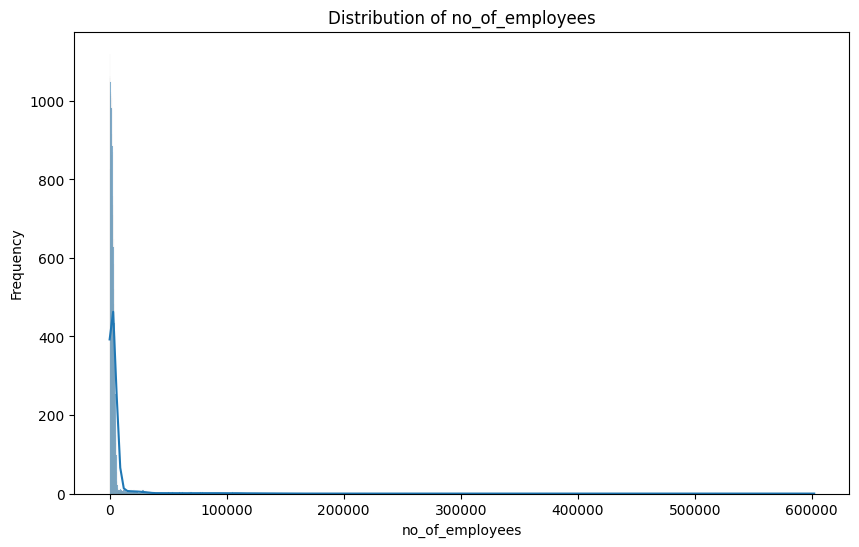

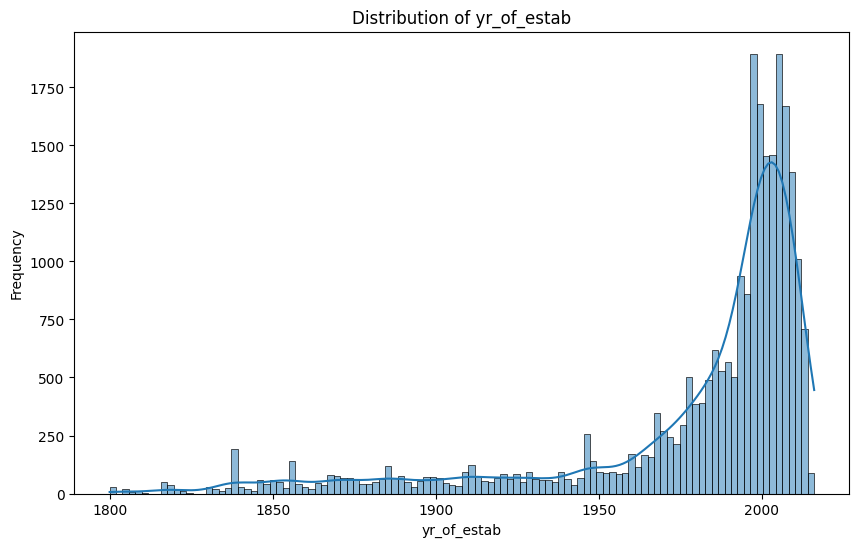

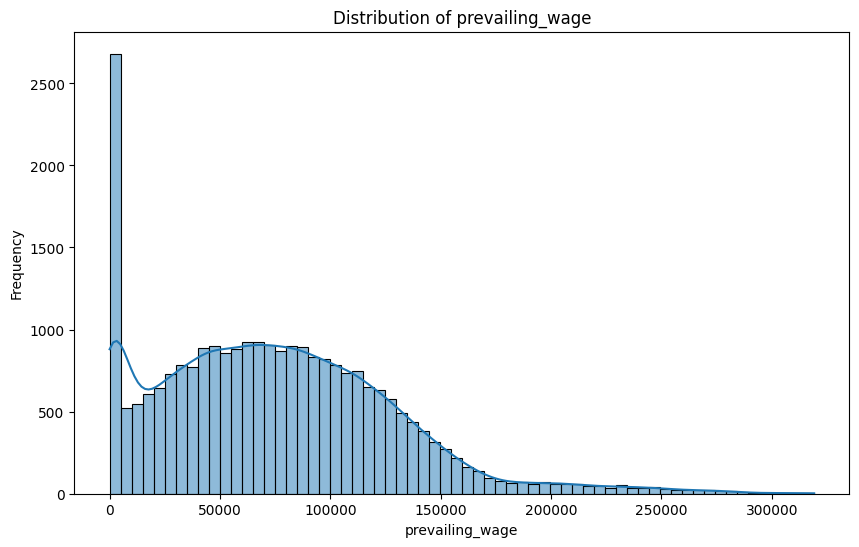

In [ ]:
# Distribution for each numerical column
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

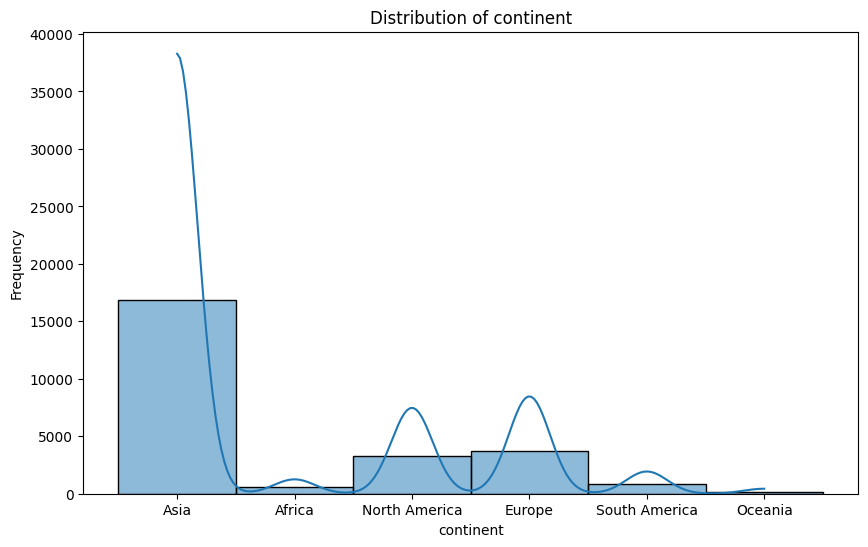

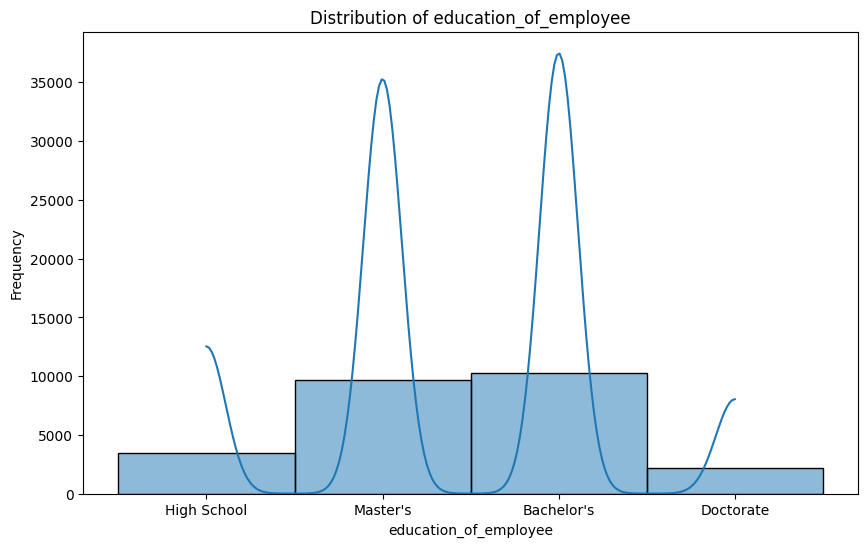

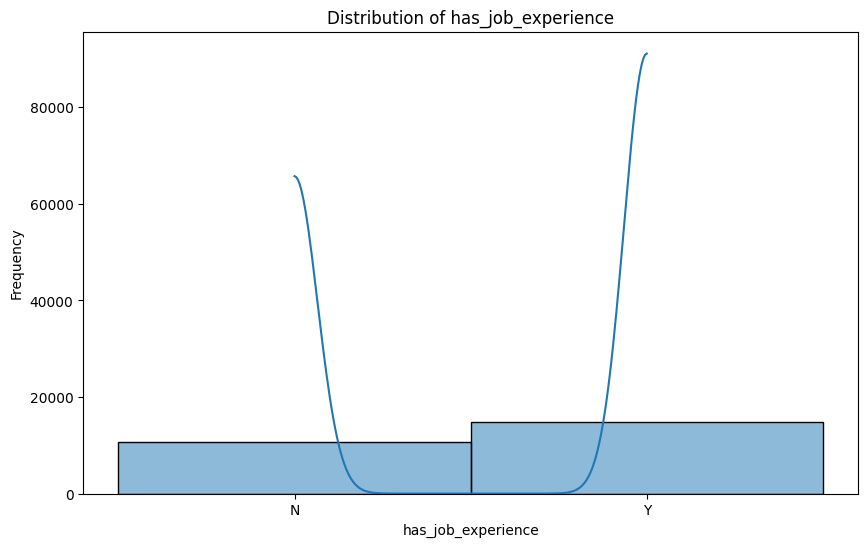

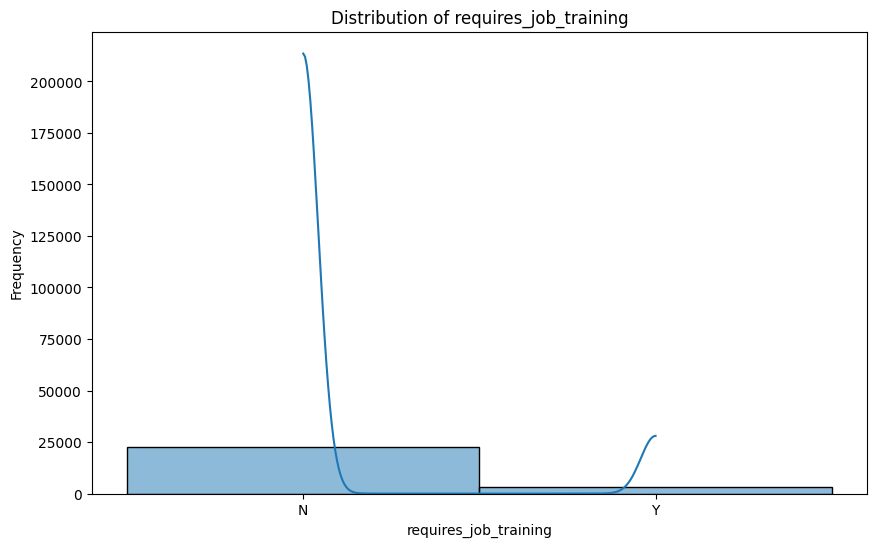

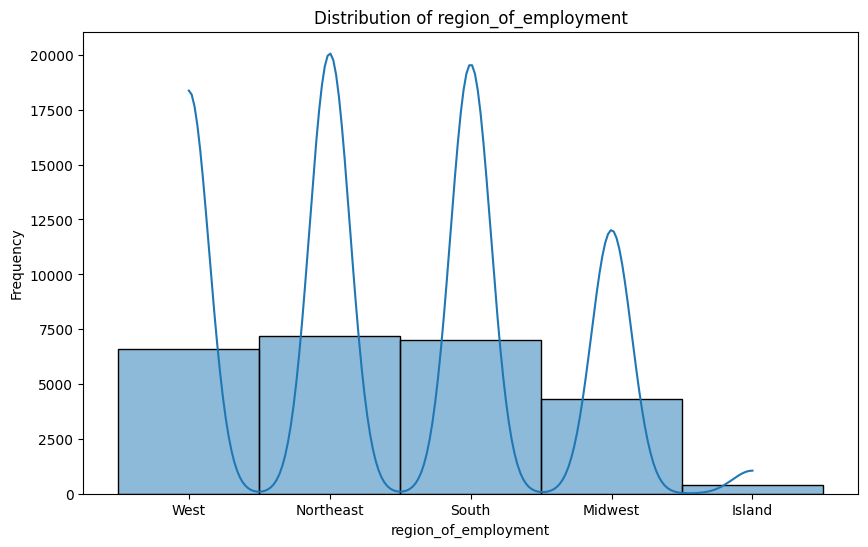

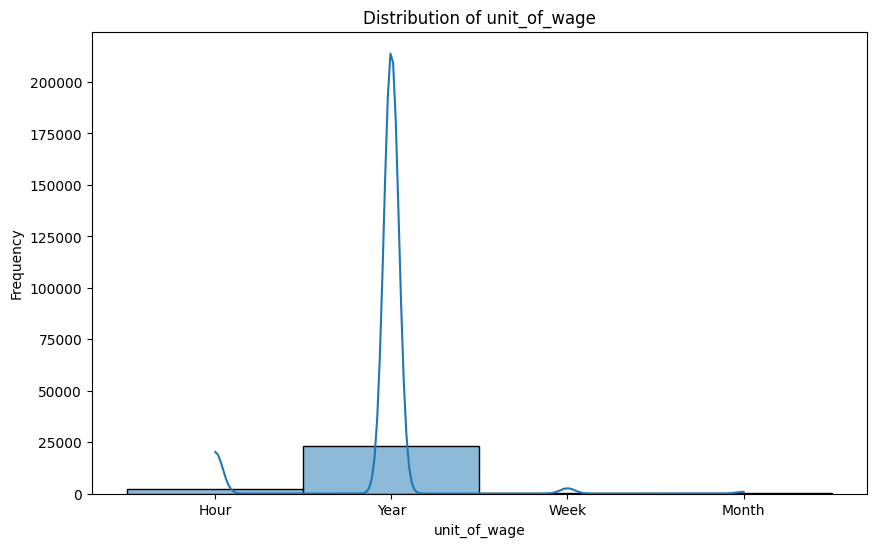

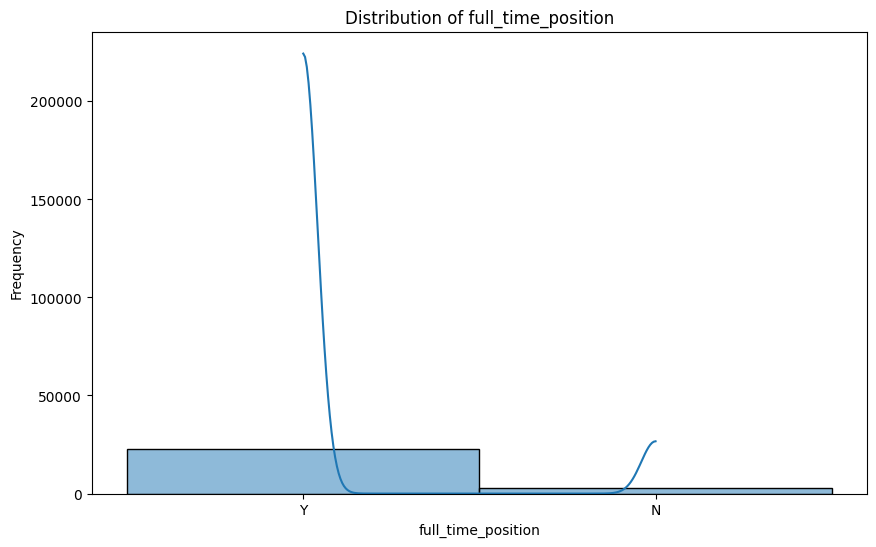

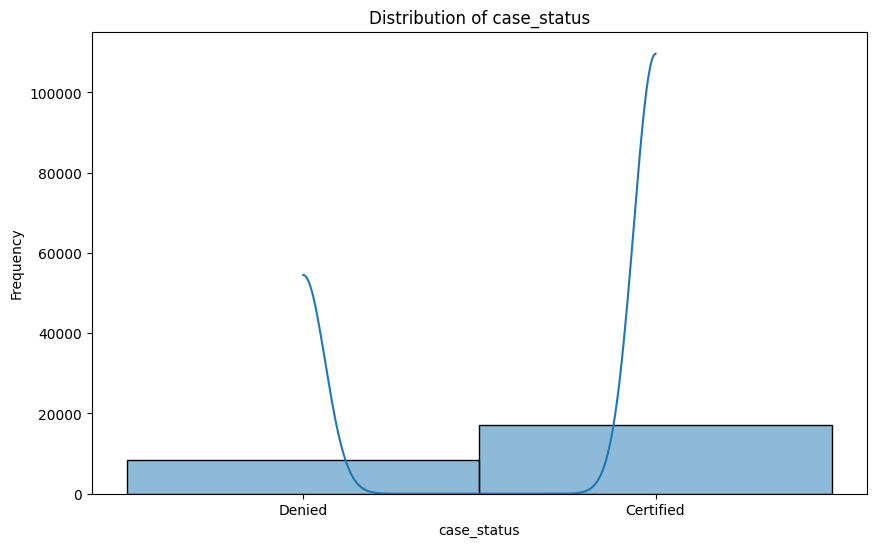

In [ ]:
# Distribution of each categorical column
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
for col in categorical_cols:
  print(f"Value counts for {col}: {df[col].value_counts()}\n")
  print(f"Normalized value counts in percentage: {100*df[col].value_counts(normalize=True)}\n")

Value counts for continent: continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

Normalized value counts in percentage: continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64

Value counts for education_of_employee: education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

Normalized value counts in percentage: education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64

Value counts for has_job_experience: has_job_experience
Y    14802
N    10678
Name: count, dtype: int64

Normalized value counts in percentage: has_job_experience
Y    58.092622
N    4

## Univariate Analysis Summary

Most of the applicants applying for U.S. visas are from Asia (around 66.2%), with a small but noticeable number from Europe (14.6%) or North America (12.9%) and very few from South America (3.3%), Africa (2.2%), or Oceania (0.8%)

Most of the applicants have a Bachelor's (40.2%) or Master's (37.8%) as their highest level of education, but a very significant number have high school (13.4%) or Doctorate (8.6%) as their highest level of education

Most applicants have job experience (58.1%) versus not (41.9%), but the difference is not too large in relative terms


Relatively few applicants require job training (11.6%) and majority of applicants (88.4%) do not


The distribution of 'no_of_employees' is extremely right-skewed with the vast majority of companies having very few employees and very few companies having an extremely high number of employees

The distribution of 'yr_of_estab' is highly left-skewed with the vast majority of companies established closer to the year 2000 and few but still noticeable numbers of companies established in the 1800s and early to mid 1900s


Relatively very few applicants are applying to jobs in the Island region (1.5%) of the United States, a large amount are applying to jobs in the Midwest (16.9%), and the majority are applying to jobs in the West (25.8%), South (27.5%), or Northeast (28.2%)


A lot of the prevailing_wage is very close to 0, but that is likely because we have not segmented prevailing_wage by the unit_of_wage. However, for the values of prevailing_wage that likely correspond to a yearly salary (due to being in the tens of thousands), we see a right-skewed distribution.
> We can  redo the distribution for prevailing_wage once we account for the different 'unit_of_wage' values in the feature engineering

The vast majority of applicants have their unit_of_wage being yearly (90.1%) but a few have their unit_of_wage being hourly (8.5%), and extremely few have their unit_of_wage being weekly (1.1%) or monthly (0.3%)


Most of the applicants are intending to take on full-time positions (89.4%) (with 10.6% not intending to take on full-time positions)

Most of the applications were certified (66.8%), but a noticeable amount (33.2%) were denied

## Bivariate Analysis

### Bivariate Analysis on Categorical Columns

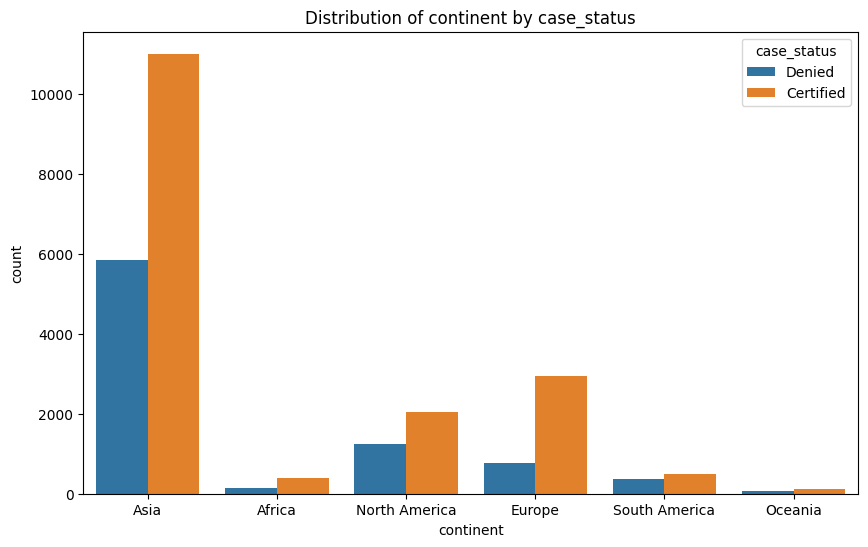

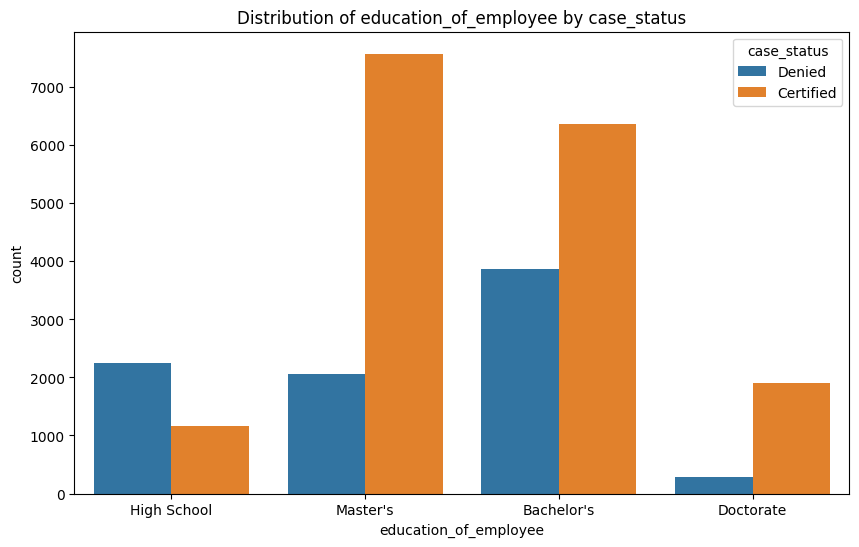

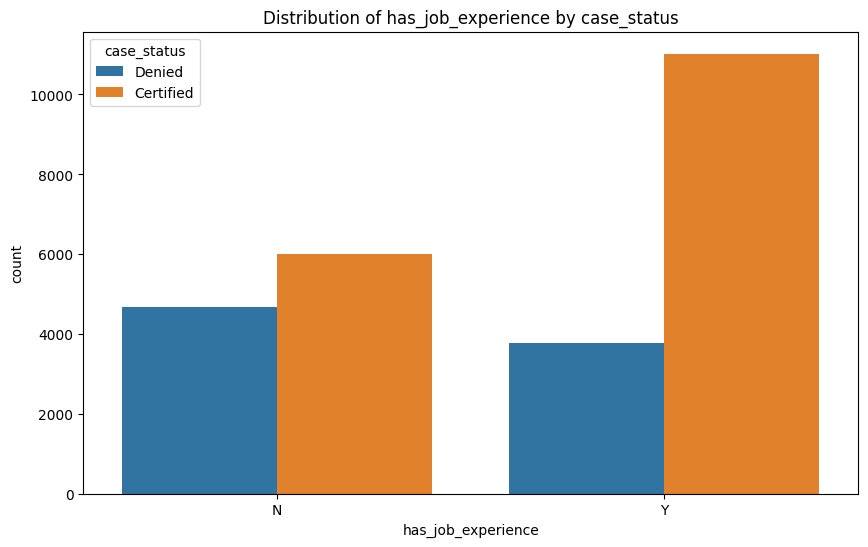

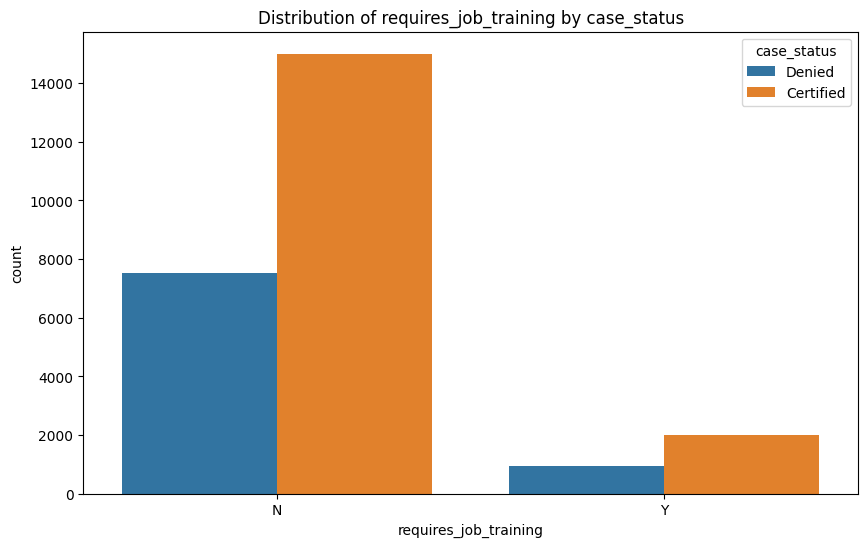

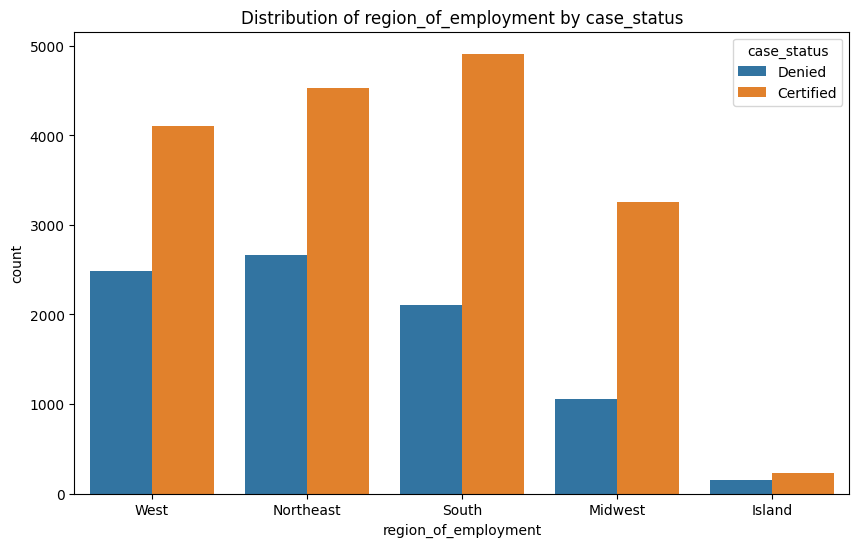

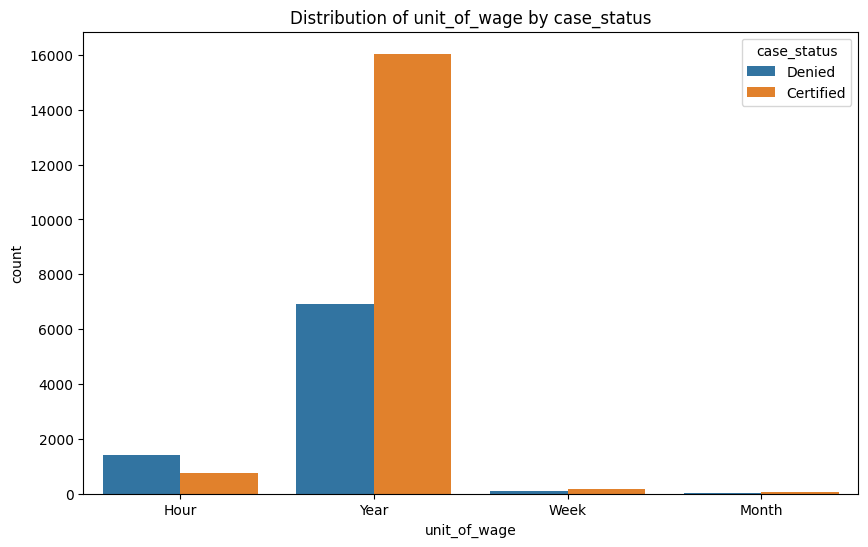

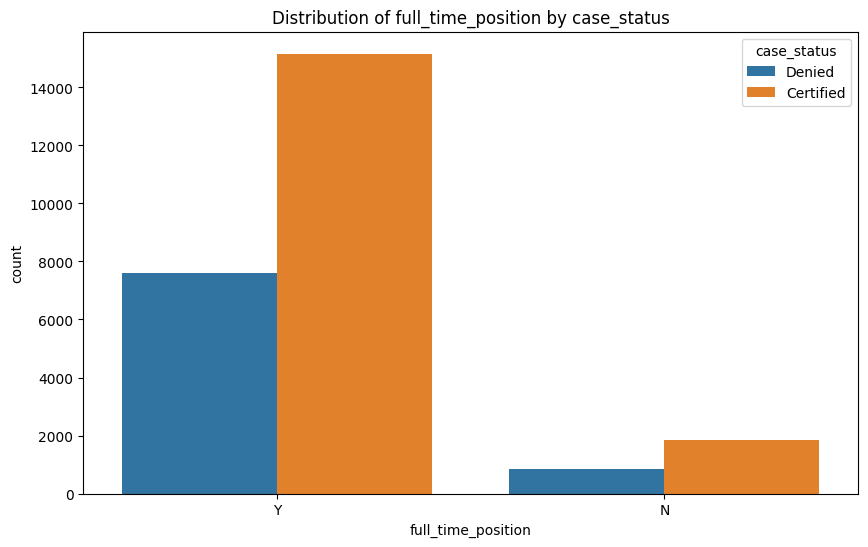

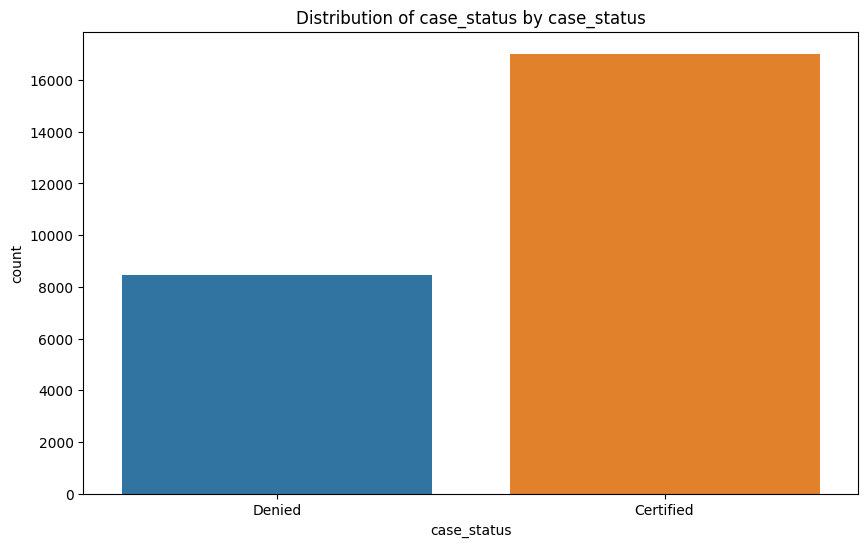

In [ ]:
# Compare each categorical column to case status
for col in categorical_cols:
  col_countplot_hue(df, col, 'case_status')

In [ ]:
for col in categorical_cols:
  print(counts_case_status(df, col))
  print('\n')

continent      case_status
Africa         Certified        397
               Denied           154
Asia           Certified      11012
               Denied          5849
Europe         Certified       2957
               Denied           775
North America  Certified       2037
               Denied          1255
Oceania        Certified        122
               Denied            70
South America  Certified        493
               Denied           359
dtype: int64


education_of_employee  case_status
Bachelor's             Certified      6367
                       Denied         3867
Doctorate              Certified      1912
                       Denied          280
High School            Certified      1164
                       Denied         2256
Master's               Certified      7575
                       Denied         2059
dtype: int64


has_job_experience  case_status
N                   Certified       5994
                    Denied          4684
Y                 

In [ ]:
for col in categorical_cols:
  print(relative_freq_case_status(df, col))
  print('\n')

continent      case_status
Africa         Certified      72.1
               Denied         27.9
Asia           Certified      65.3
               Denied         34.7
Europe         Certified      79.2
               Denied         20.8
North America  Certified      61.9
               Denied         38.1
Oceania        Certified      63.5
               Denied         36.5
South America  Certified      57.9
               Denied         42.1
dtype: float64


education_of_employee  case_status
Bachelor's             Certified      62.2
                       Denied         37.8
Doctorate              Certified      87.2
                       Denied         12.8
High School            Certified      34.0
                       Denied         66.0
Master's               Certified      78.6
                       Denied         21.4
dtype: float64


has_job_experience  case_status
N                   Certified      56.1
                    Denied         43.9
Y                   Certifie

### Bivariate Analysis on Numerical Columns

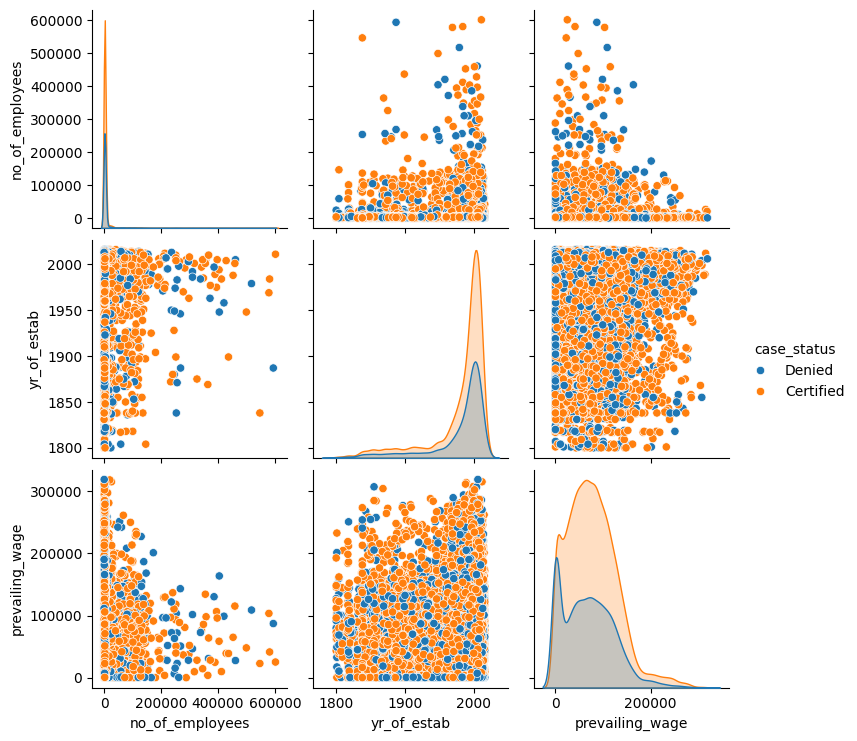

In [ ]:
sns.pairplot(data=df, vars=numerical_cols, hue='case_status')
plt.show()

> Using the kernel density estimations, the certification rate is very high for the companies with the top few highest numbers of employees and noticeably higher for greater (IE more recent) years of establishment and prevailing wages

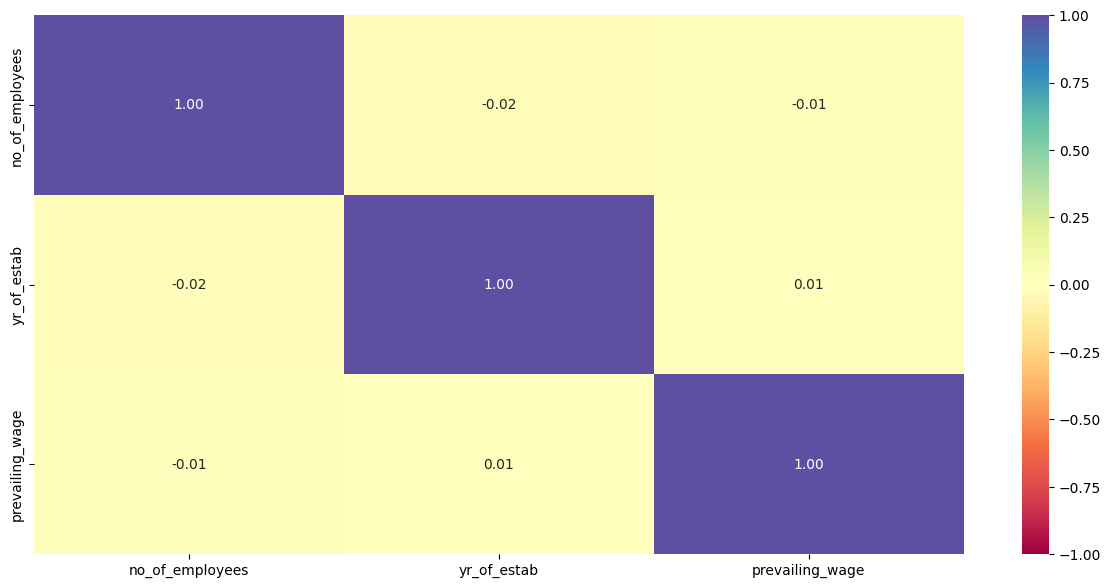

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(df[numerical_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

I note that here, the unit_of_wage matters a lot

#### Case status vs Prevailing Wage

Unit of wage: Hour


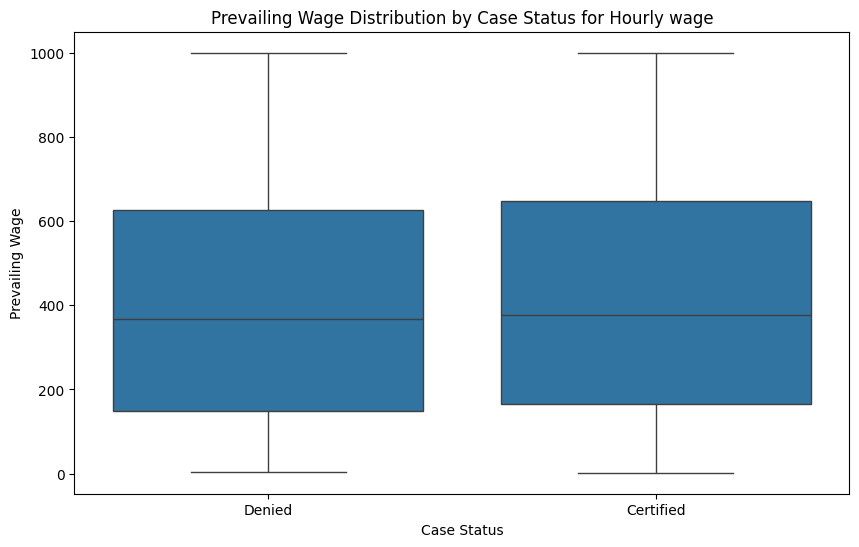

Unit of wage: Year


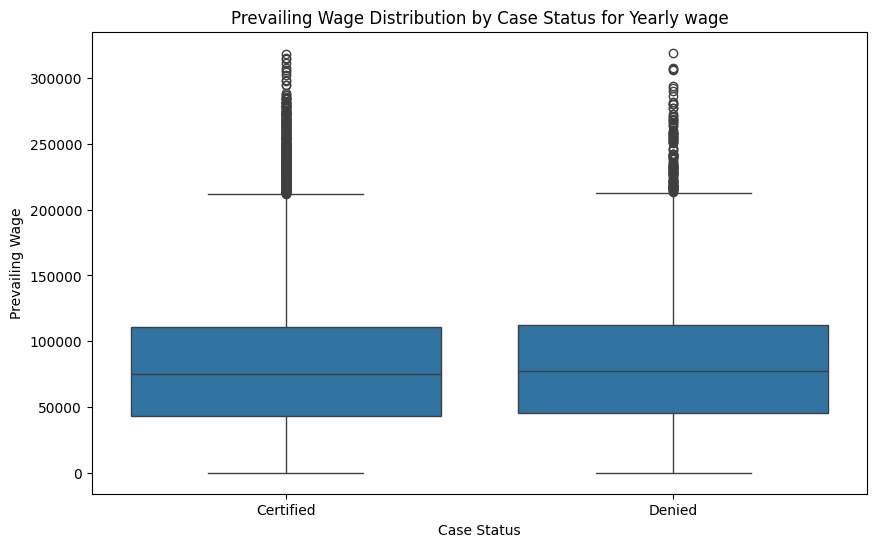

Unit of wage: Week


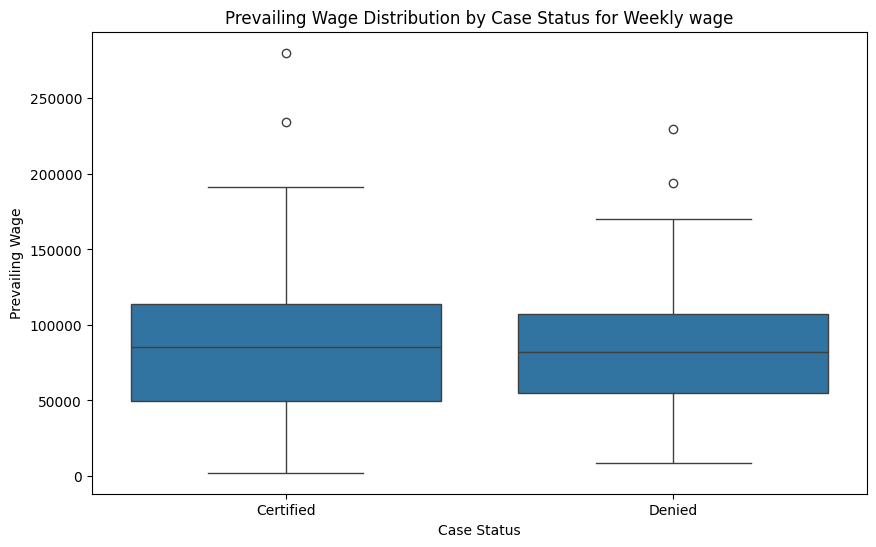

Unit of wage: Month


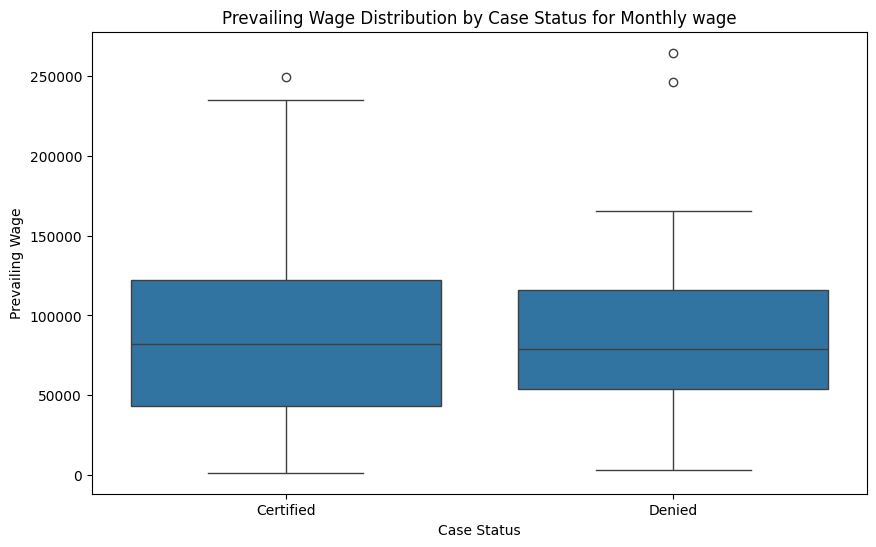

In [ ]:
for unit_of_wage in df['unit_of_wage'].unique():
  print(f"Unit of wage: {unit_of_wage}")
  plt.figure(figsize=(10, 6))
  sns.boxplot(x='case_status', y='prevailing_wage', data=df[df['unit_of_wage'] == unit_of_wage])
  plt.title(f'Prevailing Wage Distribution by Case Status for {unit_of_wage}ly wage')
  plt.xlabel('Case Status')
  plt.ylabel('Prevailing Wage')
  plt.show()

In [ ]:
# Compare metrics directly
print("Comparing prevailing wage statistics by case status\n")
for unit_of_wage in df['unit_of_wage'].unique():
    print(f"Unit of wage: {unit_of_wage}")
    print(df[df['unit_of_wage'] == unit_of_wage].groupby(['case_status'])['prevailing_wage'].describe())
    print("\n")

Comparing prevailing wage statistics by case status

Unit of wage: Hour
              count        mean         std     min       25%        50%  \
case_status                                                                
Certified     747.0  424.922811  279.668255  2.1367  165.0661  376.67030   
Denied       1410.0  409.085998  272.458156  2.9561  147.6450  367.79305   

                   75%       max  
case_status                       
Certified    646.76250  999.1929  
Denied       626.42605  999.9195  


Unit of wage: Year
               count          mean           std     min        25%       50%  \
case_status                                                                     
Certified    16047.0  80746.407044  50481.509835  100.00  42988.735  75427.84   
Denied        6915.0  82345.844294  48684.484971  153.11  45450.430  77697.21   

                    75%        max  
case_status                         
Certified    110654.055  318446.05  
Denied       112564.340  3

#### Case status vs. Number of Employees

In [ ]:
# Compare metrics directly
print("Comparing no. employees statistics by case status\n")
print(df.groupby(['case_status'])['no_of_employees'].describe())
print("\n")

Comparing no. employees statistics by case status

               count         mean           std   min      25%     50%  \
case_status                                                              
Certified    17018.0  5807.018157  23119.575259 -26.0  1035.25  2147.0   
Denied        8462.0  5385.538407  22382.755904 -26.0   991.00  2032.5   

                 75%       max  
case_status                     
Certified    3575.00  602069.0  
Denied       3386.75  594472.0  




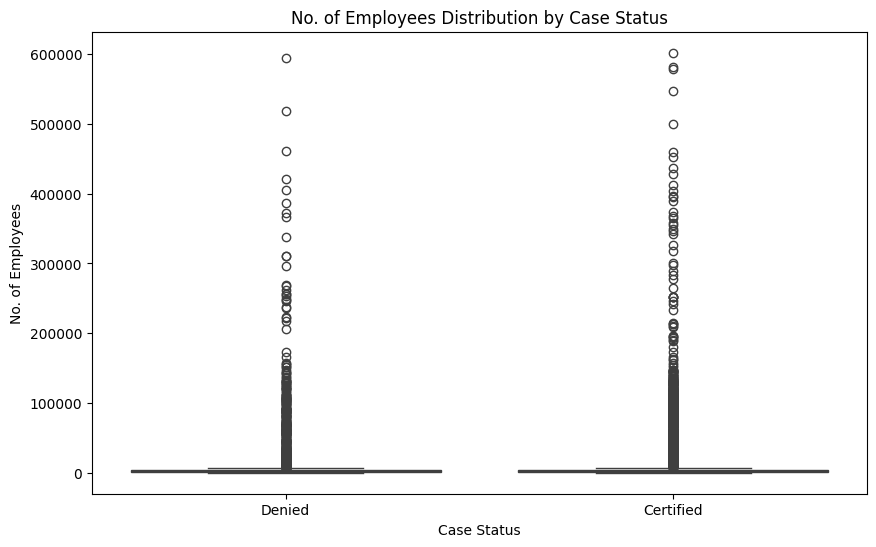

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='case_status', y='no_of_employees', data=df)
plt.title('No. of Employees Distribution by Case Status')
plt.xlabel('Case Status')
plt.ylabel('No. of Employees')
plt.show()

#### Case Status vs Year of Establishment

In [ ]:
# Compare metrics directly
print("Comparing year of establishment statistics by case status\n")
print(df.groupby(['case_status'])['yr_of_estab'].describe())
print("\n")

Comparing year of establishment statistics by case status

               count         mean        std     min     25%     50%     75%  \
case_status                                                                    
Certified    17018.0  1979.666765  42.278601  1800.0  1976.0  1997.0  2005.0   
Denied        8462.0  1978.893406  42.541819  1800.0  1975.0  1997.0  2004.0   

                max  
case_status          
Certified    2016.0  
Denied       2016.0  




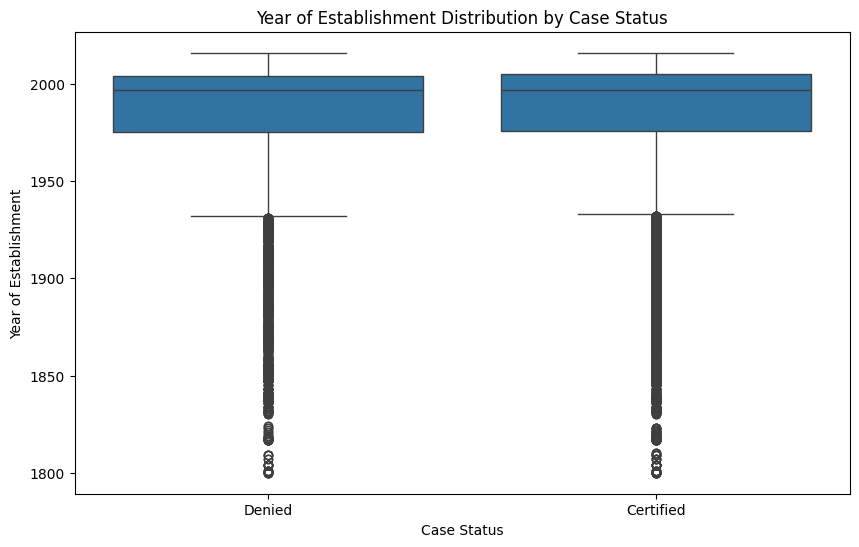

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='case_status', y='yr_of_estab', data=df)
plt.title('Year of Establishment Distribution by Case Status')
plt.xlabel('Case Status')
plt.ylabel('Year of Establishment')
plt.show()

## Bivariate Analysis Summary

It seems that approximately 79.2% of visas from Europe, 72.1% of visas from Africa, 65.3% from Asia, 63.5% from Oceania, 61.9% from North America, and 57.9% from South America are approved

>Visas from Europe are much more likely to be approved and visas from Africa are significantly more likely to be approved than visas from other continents

Around 87.2% of Doctorates were approved, compared to around 78.6% of Masters, 62.2% of Bachelors, and 34.0% of High School-only
> From this, it is safe to say that higher education gives a higher chance for approval, and this would make sense in the real-world context

Those who have job experience have a significantly higher likelihood (approximately 74.5%) of being certified versus those who have no job experience (approx. 56.1%)

Around 67.9% of applicants who required job training were certified, compared to 66.6% of applicants who did not require job training

> As such, it doesn't seem that requiring job training versus not makes much of a difference in the chances of being certified

In the U.S., the Island region approves approximately 60.3% of visas, the Midwest region approximately 75.5%, the Northeast region approximately 62.9%, the South approximately 70.0%, and the West region approximately 62.2%

> In short, the Midwest region is significantly more likely and the South noticeably more likely to approve a visa than the other regions (Island, Northeast, and West)

Those with a unit of wage in hours were unlikely to be certified (34.6%), compared to those with a weekly wage (62.1%), montly wage (61.8%), or yearly wage (69.9%)

Positions being full-time or not did not seem to have much of an effect on being certified, as full-time positions had a 66.6% certification rate compared to non-full time positions with a 68.5% certification rate

Here, none of the numerical features (no_of_employees, yr_of_estab, or prevailing_wage) seem to be significantly correlated to each other

According to the statistics, the number of employees does not seem to have a significant effect on the case status
> The boxplots for no_of_employees versus case_status are not very useful due to the vast majority of values for no_of_employees being low to medium and vastly different in scale compared to the highest values

The year of establishment doesn't seem to be affected by the case status (the means and standard deviations for year of establishment with respect to certified and denied visas are extremely close together)

The mean and standard deviation of prevailing wages are approximately the same for each unit of wage, with some significant differences in minimums and maximums

> In short, prevailing wage doesn't have a noticeable effect on case status

## Questions

Q1: For case_status, most of the cases (around 66.8%) were certified and the remaining approx. 33.2% of cases were denied

Q2: Higher education level significantly increased the chances of being approved. When the highest level of education was a Doctorate, the chance of approval was 87.2%; for a Master's, it was 78.6%; for a Bachelor's, it was 62.2%; and for High School, it was 34.0%

Q3: The certification rate was indeed much higher (≈74.5%) for applicants with job experience versus those without prior job experience (≈56.1%)

Q4: Prevailing wage does not seem to have a significant effect on visa approval rates

Q5: The Midwest region had a very high approval rate (75.5%) compared to the other regions, being South (70.0%), Northeast (62.9%), West (62.2%), and Island (60.3%)

Q6: The number of employees does not seem to have a significant impact on the distribution of certifications versus denials

Q7: The continent of origin does indeed have a noticeable effect on visa approval rates. It seems that approximately 79.2% of visas from Europe, 72.1% of visas from Africa, 65.3% from Asia, 63.5% from Oceania, 61.9% from North America, and 57.9% from South America are approved
> Visas are most likely to be approved from Europe and least likely to be approved from South America

## Missing or erroneous value checks

In [ ]:
print(df.isnull().sum())

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


> Here, there are no missing values

In [ ]:
# Check the data for typos
for col in categorical_cols:
    print(f"Unique values in column '{col}':")
    print(df[col].unique())

Unique values in column 'continent':
['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']
Unique values in column 'education_of_employee':
['High School' "Master's" "Bachelor's" 'Doctorate']
Unique values in column 'has_job_experience':
['N' 'Y']
Unique values in column 'requires_job_training':
['N' 'Y']
Unique values in column 'region_of_employment':
['West' 'Northeast' 'South' 'Midwest' 'Island']
Unique values in column 'unit_of_wage':
['Hour' 'Year' 'Week' 'Month']
Unique values in column 'full_time_position':
['Y' 'N']
Unique values in column 'case_status':
['Denied' 'Certified']


> Here, we see no typos in the categorical columns

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    print(f"Number of negative values in '{col}':")
    print(df[df[col] < 0][col].count())

Number of negative values in 'no_of_employees':
33
Number of negative values in 'yr_of_estab':
0
Number of negative values in 'prevailing_wage':
0


In [ ]:
for col in numerical_cols:
    print(f"Number of zero values in '{col}':")
    print(df[df[col] == 0][col].count())

Number of zero values in 'no_of_employees':
0
Number of zero values in 'yr_of_estab':
0
Number of zero values in 'prevailing_wage':
0


In [ ]:
print(df[df['no_of_employees'] < 0])

         case_id      continent education_of_employee has_job_experience  \
245      EZYV246         Europe              Master's                  N   
378      EZYV379           Asia            Bachelor's                  N   
832      EZYV833  South America              Master's                  Y   
2918    EZYV2919           Asia              Master's                  Y   
6439    EZYV6440           Asia            Bachelor's                  N   
6634    EZYV6635           Asia            Bachelor's                  Y   
7224    EZYV7225         Europe             Doctorate                  N   
7281    EZYV7282           Asia           High School                  N   
7318    EZYV7319           Asia            Bachelor's                  Y   
7761    EZYV7762           Asia              Master's                  N   
9872    EZYV9873         Europe              Master's                  Y   
11493  EZYV11494           Asia           High School                  Y   
13471  EZYV1

> Here, there are negative values in 'no_of_employees' that we must take care of

> In a real-world setting, we could consult the people who gave us the data and ask if the negative values had meaning or were accidental. For our case, since it's only 33 rows and the negative values had low absolute values, I will impute them with their positive counterparts

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)


Here are my steps:

> Remove case_id

> One-hot encode continent, education_of_employee, has_job_experience, requires_job_training, region_of_employmnent unit_of_wage, full_time_position, and case_status

> Impute no_of_employees with absolute values

> Create a column for total wage by multiplying prevailing_wage by a factor corresponding to the unit of wage for an 8-hour workday on all weekdays a week, including common U.S. holidays

## Feature Engineering

In [ ]:
if 'numerical_cols_v1' not in globals():
  numerical_cols_v1 = numerical_cols.copy()
if 'categorical_cols_v1' not in globals():
  categorical_cols_v1 = categorical_cols.copy()

In [ ]:
# Remove case_id
df = df.drop('case_id', axis=1)

In [ ]:
# Make all no_of_employees values non-negative
df['no_of_employees'] = df['no_of_employees'].abs()

In [ ]:
df = pd.get_dummies(df, columns=['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position'])
df['case_status'] = df['case_status'].map({'Certified': 1, 'Denied': 0})

In [ ]:
print(df.head())

   no_of_employees  yr_of_estab  prevailing_wage  case_status  \
0            14513         2007         592.2029            0   
1             2412         2002       83425.6500            1   
2            44444         2008      122996.8600            0   
3               98         1897       83434.0300            0   
4             1082         2005      149907.3900            1   

   continent_Africa  continent_Asia  continent_Europe  \
0             False            True             False   
1             False            True             False   
2             False            True             False   
3             False            True             False   
4              True           False             False   

   continent_North America  continent_Oceania  continent_South America  ...  \
0                    False              False                    False  ...   
1                    False              False                    False  ...   
2                    False   

> Now to create a column for total wage

> I will do this by estimating the number of working days in a year to be a consistent value of 250

In [ ]:
num_working_days = 250
num_working_hours = num_working_days * 8
num_working_weeks = num_working_days / 7
num_working_months = num_working_days / 30

# Initialize yearly_wage column with NaN to ensure it exists
df['yearly_wage'] = np.nan

# Convert 'Hour' wages to yearly
df.loc[df['unit_of_wage_Hour'] == True, 'yearly_wage'] = df['prevailing_wage'] * num_working_hours

# Convert 'Week' wages to yearly
df.loc[df['unit_of_wage_Week'] == True, 'yearly_wage'] = df['prevailing_wage'] * num_working_weeks

# Convert 'Month' wages to yearly
df.loc[df['unit_of_wage_Month'] == True, 'yearly_wage'] = df['prevailing_wage'] * num_working_months

# For 'Year' wages, it's already yearly, so assign directly
df.loc[df['unit_of_wage_Year'] == True, 'yearly_wage'] = df['prevailing_wage']

df.drop('prevailing_wage', axis=1, inplace=True) # to prevent the model from being confused

In [ ]:
df['yearly_wage'].describe()

,yearly_wage
count,2.548000e+04
mean,1.785789e+05
std,4.357021e+05
min,1.000000e+02
25%,4.709736e+04
50%,8.281055e+04
75%,1.247497e+05
max,1.000628e+07


In [ ]:
numerical_cols = pd.Index(list(numerical_cols) + ['yearly_wage'])
numerical_cols = numerical_cols.drop('prevailing_wage')
# After pd.get_dummies, the original 'object' columns are replaced by boolean dummy columns.
# We need to re-identify the categorical feature columns (which are now boolean) and exclude the target 'case_status' dummy columns.
all_new_categorical_cols = df.select_dtypes(include=['bool']).columns
target_dummy_cols = [col for col in all_new_categorical_cols if col.startswith('case_status_')]
categorical_cols = all_new_categorical_cols.drop(target_dummy_cols)

In [ ]:
if 'dfv2' not in globals():
  dfv2 = df.copy()
if 'numerical_cols_v2' not in globals():
  numerical_cols_v2 = numerical_cols.copy()
if 'categorical_cols_v2' not in globals():
  categorical_cols_v2 = categorical_cols.copy()

## Outlier treatment

> I note that, while yr_of_estab is highly left-skewed, it doesn't seem to have much of an effect on case_status, so I will leave yr_of_estab as is

>

> While Oceania makes up only 0.8% of applicants' continents, I do not see much of a difference in certification rates for applicants from Oceania versus other continents, and it also doesn't make sense to remove consideration for Oceania continent from our model; on top of that, I believe a good model can give good attention to the differences in continents, so I would rather have some data for Oceania than none at all. As such, I will leave this as is.

> unit_of_wage = 'Monthly' made up around 0.3% of applications, but it wouldn't make sense to stop considering applicants with monthly wages entirely, and the certification rate for monthly wages is not too different from that for weekly or yearly wages. On top of that, a good model could likely give good attention to the separate categories of unit_of_wage, so I'd rather have some data for unit_of_wage = 'Monthly' than none at all.

> no_of_employees is highly right-skewed, however the mean and standard deviation for no_of_employees is approximately equal for both case_status = Denied and Certified. It might still be helpful to remove some outliers, as there are some extremely high values that could skew our models. **I will investigate that**

> prevailing_wage is definitely right-skewed for the rows that have unit_of_wage in years. I will remove outliers with respect to yearly wage for all units of wage, and this should deal with the outliers for all values of unit_of_wage

> Finally, there could be some very high outliers in our yearly_wage column (hint: see the max compared to the mean and standard deviation in our yearly_wage statistics) that could skew our model, so I will investigate those as well.

In [ ]:
# Outlier detection based on z-score for no_of_employees
z_scores_no_employees = np.abs((df['no_of_employees'] - df['no_of_employees'].mean()) / df['no_of_employees'].std())
for z_threshold in [3, 4, 5, 6, 7, 8, 9, 10]:
  outlier_indices = np.where(np.abs(z_scores_no_employees) > z_threshold)[0]
  print(f"Number of outliers in no_of_employees with z-score greater in magnitude than {z_threshold}: {len(outlier_indices)}")
print('\n\n')
z_scores_yearly_wage = np.abs((df['yearly_wage'] - df['yearly_wage'].mean()) / df['yearly_wage'].std())
for z_threshold in [3, 4, 5, 6, 7, 8, 9, 10]:
  outlier_indices = np.where(np.abs(z_scores_yearly_wage) > z_threshold)[0]
  print(f"Number of outliers in yearly_wage with z-score greater in magnitude than {z_threshold}: {len(outlier_indices)}")

Number of outliers in no_of_employees with z-score greater in magnitude than 3: 429
Number of outliers in no_of_employees with z-score greater in magnitude than 4: 283
Number of outliers in no_of_employees with z-score greater in magnitude than 5: 171
Number of outliers in no_of_employees with z-score greater in magnitude than 6: 102
Number of outliers in no_of_employees with z-score greater in magnitude than 7: 79
Number of outliers in no_of_employees with z-score greater in magnitude than 8: 74
Number of outliers in no_of_employees with z-score greater in magnitude than 9: 66
Number of outliers in no_of_employees with z-score greater in magnitude than 10: 59



Number of outliers in yearly_wage with z-score greater in magnitude than 3: 572
Number of outliers in yearly_wage with z-score greater in magnitude than 4: 247
Number of outliers in yearly_wage with z-score greater in magnitude than 5: 178
Number of outliers in yearly_wage with z-score greater in magnitude than 6: 155
Number o

In [ ]:
z_scores_no_employees_sorted = np.sort(z_scores_no_employees)
print(z_scores_no_employees_sorted[-30:])
print('\n\n')

z_scores_yearly_wage_sorted = np.sort(z_scores_yearly_wage)
print(z_scores_yearly_wage_sorted[-30:])

[14.70644832 14.8914302  15.00936051 15.30117029 15.41595346 15.68188676
 15.78045342 15.80755379 16.01530872 16.07165126 16.63660653 16.7815935
 17.01439441 17.12100376 17.40944785 17.44249281 17.76997017 18.15702463
 18.49407454 18.85647641 19.55925017 19.83497457 19.9257608  21.59518723
 22.38914061 23.66932707 25.06071245 25.16841456 25.73682294 26.06888988]



[10.93975305 11.17225712 11.38912304 11.41299666 11.45920124 11.58394162
 11.75728337 11.78494153 11.82709763 11.94261317 12.08219331 12.21816516
 12.33848985 12.8445852  12.89361773 13.32677087 13.34559107 13.45373509
 13.54379991 13.54746559 13.68673999 13.74524819 13.75454927 13.85664066
 14.83140327 15.28912513 15.47098105 18.4390824  18.80431068 22.55602172]


> With some extremely strong z-scores existing (remember, this is based on the absolute values of z-scores), I will remove up to 200 rows in the dataset to prevent model skewness while also trying to preserve information. 200 rows is still relatively a lot given it's around 1% of our dataset, but I feel that the reduction in model skewness will pay off.

In [ ]:
# Remove rows with np.abs(z_scores_no_employees) > 6
no_employees_z_threshold = 6
df = df[np.abs(z_scores_no_employees) <= no_employees_z_threshold]
z_scores_yearly_wage = np.abs((df['yearly_wage'] - df['yearly_wage'].mean()) / df['yearly_wage'].std())
for z_threshold in [5, 6, 7, 8, 9, 10]:
  outlier_indices = np.where(np.abs(z_scores_yearly_wage) > z_threshold)[0]
  print(f"Number of outliers in yearly_wage with z-score greater in magnitude than {z_threshold}: {len(outlier_indices)}")

Number of outliers in yearly_wage with z-score greater in magnitude than 5: 177
Number of outliers in yearly_wage with z-score greater in magnitude than 6: 154
Number of outliers in yearly_wage with z-score greater in magnitude than 7: 121
Number of outliers in yearly_wage with z-score greater in magnitude than 8: 86
Number of outliers in yearly_wage with z-score greater in magnitude than 9: 64
Number of outliers in yearly_wage with z-score greater in magnitude than 10: 42


In [ ]:
# Remove rows with np.abs(yearly_wage) > 7
yearly_wage_z_threshold = 7
df = df[np.abs(z_scores_yearly_wage) <= yearly_wage_z_threshold]

In [ ]:
print(df.shape)

(25257, 29)


> Here, we originally had 25,480 rows, and now we have 25,257 rows, meaning we only removed 233 rows. Let's explore the maximum z-score magnitudes now

In [ ]:
z_scores_no_employees = np.abs((df['no_of_employees'] - df['no_of_employees'].mean()) / df['no_of_employees'].std()) # recalculate after we removed even more rows
z_scores_yearly_wage = np.abs((df['yearly_wage'] - df['yearly_wage'].mean()) / df['yearly_wage'].std()) # recalculate along with z_scores_no_employees

z_scores_no_employees_sorted = np.sort(z_scores_no_employees)
print(z_scores_no_employees_sorted[-30:])
print('\n\n')

z_scores_yearly_wage_sorted = np.sort(z_scores_yearly_wage)
print(z_scores_yearly_wage_sorted[-30:])

[ 9.68876363  9.69810809  9.72499256  9.73571571  9.73992837  9.74689842
  9.75785135  9.77087232  9.80495661  9.81989243  9.8467003   9.86278503
  9.94918297  9.95285948 10.0030285  10.01030492 10.03175122 10.04002337
 10.08988601 10.1631864  10.2626819  10.27685178 10.28060488 10.3130807
 10.32816971 10.33069731 10.44535841 10.44857536 10.57740634 10.58491254]



[8.61455243 8.67895467 8.70620216 8.77799722 8.78237276 8.86194527
 8.88659799 8.9017166  8.90281307 8.91067893 8.94937446 9.05261689
 9.1279769  9.16008445 9.21926956 9.25312686 9.26486996 9.28448237
 9.29448261 9.40080778 9.53429547 9.53663422 9.55210991 9.56624572
 9.71054998 9.75484037 9.76049148 9.76772127 9.79353934 9.8149991 ]


> This seems satisfactory to me

In [ ]:
if 'dfv3' not in globals():
  dfv3 = df.copy()
if 'numerical_cols_v3' not in globals():
  numerical_cols_v3 = numerical_cols.copy()
if 'categorical_cols_v3' not in globals():
  categorical_cols_v3 = categorical_cols.copy()

In [ ]:
print(df.head())

   no_of_employees  yr_of_estab  case_status  continent_Africa  \
0            14513         2007            0             False   
1             2412         2002            1             False   
2            44444         2008            0             False   
3               98         1897            0             False   
4             1082         2005            1              True   

   continent_Asia  continent_Europe  continent_North America  \
0            True             False                    False   
1            True             False                    False   
2            True             False                    False   
3            True             False                    False   
4           False             False                    False   

   continent_Oceania  continent_South America  \
0              False                    False   
1              False                    False   
2              False                    False   
3              False  

# **Model Building**

## Model Building / Testing Helper Functions

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from xgboost import XGBClassifier

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

In [ ]:
def model_evaluate(model, X_test, y_test, display_confusion_matrix=True):
  y_test_pred = model.predict(X_test)
  # print(classification_report(y_test, y_test_pred))
  if (display_confusion_matrix == True):
    print(confusion_matrix(y_test, y_test_pred))
  print(f"Accuracy: {accuracy_score(y_test, y_test_pred)}")
  print(f"Precision: {precision_score(y_test, y_test_pred)}")
  print(f"Recall: {recall_score(y_test, y_test_pred)}")
  print(f"F1 Score: {f1_score(y_test, y_test_pred)}")
  print(f"ROC AUC Score: {roc_auc_score(y_test, y_test_pred)}")

In [ ]:
def print_df_shapes_counts(X, y, technique):
  technique_string = ""
  if (technique != "None"):
    technique_string = f" using {technique}"

  print(f"Shape of training/validation feature set{technique_string}:\n{X.shape}")
  print(f"Shape of output {technique_string}:\n{y.shape}")
  print(f"Value counts of output{technique_string}:\n{y.value_counts()}")

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
def custom_grid_search_params(model_type): # Using the class-given hyperparameters (see below text cell) and in case my chosen model types change in future runs
  if model_type == "GradientBoostingClassifier":
    param_grid = {
      "init": [AdaBoostClassifier(random_state=42),DecisionTreeClassifier(random_state=42)],
      "n_estimators": np.arange(50,110,25),
      "learning_rate": [0.01,0.1,0.05],
      "subsample":[0.7,0.9],
      "max_features":[0.5,0.7,1]
    }
  elif model_type == "AdaBoostClassifier":
    param_grid = {
      "n_estimators": np.arange(50,110,25),
      "learning_rate": [0.01,0.1,0.05],
      "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=42),
        DecisionTreeClassifier(max_depth=3, random_state=42),
      ]
    }
  elif model_type == "BaggingClassifier":
    param_grid = {
      "max_samples": [0.8,0.9,1],
      "max_features": [0.7,0.8,0.9],
      "n_estimators" : [30,50,70]
    }
  elif model_type == "RandomForestClassifier":
    param_grid = {
      "n_estimators": [50,110,25],
      "min_samples_leaf": np.arange(1, 4),
      "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
      "max_samples": np.arange(0.4, 0.7, 0.1)
    }
  elif model_type == "DecisionTreeClassifier":
    param_grid = {
      "max_depth": np.arange(2,6),
      "min_samples_leaf": [1, 4, 7],
      "max_leaf_nodes" : [10, 15],
      "min_impurity_decrease": [0.0001,0.001]
    }
  else: #model_type == "XGBClassifier"
    param_grid = {
      "n_estimators": np.arange(50, 110, 25),
      "scale_pos_weight": [1, 2, 5],
      "learning_rate": [0.01, 0.1, 0.05],
      "gamma": [1, 3],
      "subsample": [0.7, 0.9]
    }
  return param_grid

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=42),DecisionTreeClassifier(random_state=42)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=42),
        DecisionTreeClassifier(max_depth=3, random_state=42),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


In [ ]:
def fit_evaluate_model(model, X_train, y_train, X_test, y_test, scoring_metric='f1', use_sample_weights=False):
  model.fit(X_train, y_train)
  model_evaluate(model, X_test, y_test)

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

def fit_grid(model, scoring_metric='f1', use_sample_weights=False):
  param_gid = custom_grid_search_params(model.__class__.__name__)
  grid_search = GridSearchCV(model, param_gid, cv=3, scoring=scoring_metric)

  X_fit = model.training_set[0]
  y_fit = model.training_set[1]

  if use_sample_weights:
      print(f"Applying sample weights for {model.__class__.__name__} with scoring '{scoring_metric}'")
      sample_weights = compute_sample_weight(class_weight='balanced', y=y_fit)
      grid_search.fit(X_fit, y_fit, sample_weight=sample_weights)
  else:
      print(f"Fitting {model.__class__.__name__} without sample weights for scoring '{scoring_metric}'")
      grid_search.fit(X_fit, y_fit)

  tuned_model = grid_search.best_estimator_
  return tuned_model

In [ ]:
from sklearn.utils import resample

def oversample(df, X, y):
  target_column_name = y.name # Get the name of the target column
  df_minority = df[df[target_column_name] == 0]
  df_majority = df[df[target_column_name] == 1]
  df_minority_oversampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)
  df_oversampled = pd.concat([df_majority, df_minority_oversampled])
  X_oversampled = df_oversampled.drop(target_column_name, axis=1)
  y_oversampled = df_oversampled[target_column_name]
  return X_oversampled, y_oversampled

def undersample(df, X, y):
  target_column_name = y.name # Get the name of the target column
  df_minority = df[df[target_column_name] == 0]
  df_majority = df[df[target_column_name] == 1]
  df_majority_undersampled = resample(df_majority, replace=False, n_samples=len(df_minority), random_state=42)
  df_undersampled = pd.concat([df_majority_undersampled, df_minority])
  X_undersampled = df_undersampled.drop(target_column_name, axis=1)
  y_undersampled = df_undersampled[target_column_name]
  return X_undersampled, y_undersampled

> I note that here, false positives mean certifying someone who shouldn't be certified, and false negatives mean not certifying someone who should be certified. Both of these errors can have decent consequences, but I don't see one having so much more of a consequence than the other. On top of that, I still want the model to properly predict both classes, despite there being a majority of cases being certified in this dataset; as such, I will focus on the F1 score and accuracy as my metrics of interest

## Train-Validation-Test Split

In [ ]:
X = df.drop('case_status', axis=1)
y = df['case_status']
# Now to create a training/validation/test split

# First split: 60% for training, 40% for temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Second split: 50% of temp for validation, 50% for test
# This results in 20% validation and 20% test of the original dataset
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train_and_val = pd.concat([X_train, X_val])
y_train_and_val = pd.concat([y_train, y_val])

print_df_shapes_counts(X_train, y_train, "None")
print('\n')
print_df_shapes_counts(X_val, y_val, "None")
print('\n')
print_df_shapes_counts(X_train_and_val, y_train_and_val, "None")
print('\n')
print_df_shapes_counts(X_test, y_test, "None")

Shape of training/validation feature set:
(15154, 28)
Shape of output :
(15154,)
Value counts of output:
case_status
1    10190
0     4964
Name: count, dtype: int64


Shape of training/validation feature set:
(5051, 28)
Shape of output :
(5051,)
Value counts of output:
case_status
1    3361
0    1690
Name: count, dtype: int64


Shape of training/validation feature set:
(20205, 28)
Shape of output :
(20205,)
Value counts of output:
case_status
1    13551
0     6654
Name: count, dtype: int64


Shape of training/validation feature set:
(5052, 28)
Shape of output :
(5052,)
Value counts of output:
case_status
1    3328
0    1724
Name: count, dtype: int64


In [ ]:
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_train_and_val = pd.concat([X_train_and_val, y_train_and_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

## Model Building Without Hyperparameter Tuning

### Model building without tuning, oversampling, or undersampling

Note: Here, as I am not hyperparameter tuning, I will train on the training and

In [ ]:
dtree_original = DecisionTreeClassifier(random_state=42)
fit_evaluate_model(dtree_original, X_train_and_val, y_train_and_val, X_test, y_test)

[[ 877  847]
 [ 889 2439]]
Accuracy: 0.6563737133808393
Precision: 0.7422398052343274
Recall: 0.7328725961538461
F1 Score: 0.7375264590263079
ROC AUC Score: 0.6207866461047653


In [ ]:
dtree_original_balanced = DecisionTreeClassifier(random_state=42, class_weight='balanced')
fit_evaluate_model(dtree_original_balanced, X_train_and_val, y_train_and_val, X_test, y_test)

[[ 843  881]
 [ 866 2462]]
Accuracy: 0.6541963578780681
Precision: 0.7364642536643733
Recall: 0.7397836538461539
F1 Score: 0.7381202218557937
ROC AUC Score: 0.61438138608781


In [ ]:
rf_original = RandomForestClassifier(random_state=42)
fit_evaluate_model(rf_original, X_train_and_val, y_train_and_val, X_test, y_test)

[[ 876  848]
 [ 576 2752]]
Accuracy: 0.7181314330958036
Precision: 0.7644444444444445
Recall: 0.8269230769230769
F1 Score: 0.7944572748267898
ROC AUC Score: 0.6675218632875245


In [ ]:
rf_original_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
fit_evaluate_model(rf_original_balanced, X_train_and_val, y_train_and_val, X_test, y_test)

[[ 847  877]
 [ 542 2786]]
Accuracy: 0.7191211401425178
Precision: 0.7605787605787606
Recall: 0.8371394230769231
F1 Score: 0.7970247461021314
ROC AUC Score: 0.6642193635106193


AdaBoost and Bagging would require modifications to their base estimators to incorporate balanced class weights

In [ ]:
adaboost_original = AdaBoostClassifier(random_state=42)
fit_evaluate_model(adaboost_original, X_train_and_val, y_train_and_val, X_test, y_test)

[[ 755  969]
 [ 397 2931]]
Accuracy: 0.729612034837688
Precision: 0.7515384615384615
Recall: 0.8807091346153846
F1 Score: 0.8110127282789154
ROC AUC Score: 0.6593220847090844


In [ ]:
gb_original = GradientBoostingClassifier(random_state=42)
fit_evaluate_model(gb_original, X_train_and_val, y_train_and_val, X_test, y_test)

[[ 891  833]
 [ 443 2885]]
Accuracy: 0.7474267616785432
Precision: 0.7759548144163528
Recall: 0.8668870192307693
F1 Score: 0.8189043428895827
ROC AUC Score: 0.6918541824692129


In [ ]:
bagging_original = BaggingClassifier(random_state=42)
fit_evaluate_model(bagging_original, X_train_and_val, y_train_and_val, X_test, y_test)

[[ 960  764]
 [ 771 2557]]
Accuracy: 0.696159936658749
Precision: 0.769948810599217
Recall: 0.7683293269230769
F1 Score: 0.7691382162731237
ROC AUC Score: 0.662586937243441


In [ ]:
xgboost_original = XGBClassifier(random_state=42)
fit_evaluate_model(xgboost_original, X_train_and_val, y_train_and_val, X_test, y_test)

[[ 845  879]
 [ 471 2857]]
Accuracy: 0.7327790973871734
Precision: 0.7647216274089935
Recall: 0.8584735576923077
F1 Score: 0.8088901472253681
ROC AUC Score: 0.6743063844145993


In [ ]:
# XGBoost with balanced class weights
xgboost_original_balanced = XGBClassifier(random_state=42, scale_pos_weight=1)
fit_evaluate_model(xgboost_original_balanced, X_train_and_val, y_train_and_val, X_test, y_test)

[[ 845  879]
 [ 471 2857]]
Accuracy: 0.7327790973871734
Precision: 0.7647216274089935
Recall: 0.8584735576923077
F1 Score: 0.8088901472253681
ROC AUC Score: 0.6743063844145993


### Model building with oversampling on case_status

In [ ]:
X_train_oversampled, y_train_oversampled = oversample(df_train, X_train, y_train) # for future use in hyperparameter tuning
X_val_oversampled, y_val_oversampled = oversample(df_val, X_val, y_val)
X_train_and_val_oversampled = pd.concat([X_train_oversampled, X_val_oversampled])
y_train_and_val_oversampled = pd.concat([y_train_oversampled, y_val_oversampled])

print_df_shapes_counts(X_train_and_val_oversampled, y_train_and_val_oversampled, "oversampling on case_status")

Shape of training/validation feature set using oversampling on case_status:
(27102, 28)
Shape of output  using oversampling on case_status:
(27102,)
Value counts of output using oversampling on case_status:
case_status
1    13551
0    13551
Name: count, dtype: int64


> This is indeed 50/50 on both certified and denied cases. Now to train our models again

> Note: Because it's 50/50, no need to test with the class_weights = 'balanced' parameter

In [ ]:
dtree_oversampled = DecisionTreeClassifier(random_state=42)
fit_evaluate_model(dtree_oversampled, X_train_and_val_oversampled, y_train_and_val_oversampled, X_test, y_test)

[[ 791  933]
 [ 807 2521]]
Accuracy: 0.6555819477434679
Precision: 0.7298784018529242
Recall: 0.7575120192307693
F1 Score: 0.7434385137127691
ROC AUC Score: 0.6081643622835982


In [ ]:
rf_oversampled = RandomForestClassifier(random_state=42)
fit_evaluate_model(rf_oversampled, X_train_and_val_oversampled, y_train_and_val_oversampled, X_test, y_test)

[[ 917  807]
 [ 667 2661]]
Accuracy: 0.7082343626286619
Precision: 0.7673010380622838
Recall: 0.7995793269230769
F1 Score: 0.7831077104178928
ROC AUC Score: 0.6657409395636266


In [ ]:
adaboost_oversampled = AdaBoostClassifier(random_state=42)
fit_evaluate_model(adaboost_oversampled, X_train_and_val_oversampled, y_train_and_val_oversampled, X_test, y_test)

[[1168  556]
 [ 986 2342]]
Accuracy: 0.6947743467933492
Precision: 0.8081435472739821
Recall: 0.7037259615384616
F1 Score: 0.752328943141664
ROC AUC Score: 0.6906100805372123


In [ ]:
gb_oversampled = GradientBoostingClassifier(random_state=42)
fit_evaluate_model(gb_oversampled, X_train_and_val_oversampled, y_train_and_val_oversampled, X_test, y_test)

[[1205  519]
 [ 952 2376]]
Accuracy: 0.7088281868566905
Precision: 0.8207253886010363
Recall: 0.7139423076923077
F1 Score: 0.7636188333601157
ROC AUC Score: 0.7064491120828128


In [ ]:
bagging_oversampled = BaggingClassifier(random_state=42)
fit_evaluate_model(bagging_oversampled, X_train_and_val_oversampled, y_train_and_val_oversampled, X_test, y_test)

[[1007  717]
 [ 850 2478]]
Accuracy: 0.6898258115597783
Precision: 0.7755868544600939
Recall: 0.7445913461538461
F1 Score: 0.7597731105319638
ROC AUC Score: 0.6643490373460647


In [ ]:
xgboost_oversampled = XGBClassifier(random_state=42)
fit_evaluate_model(xgboost_oversampled, X_train_and_val_oversampled, y_train_and_val_oversampled, X_test, y_test)

[[1078  646]
 [ 839 2489]]
Accuracy: 0.7060570071258907
Precision: 0.793939393939394
Recall: 0.7478966346153846
F1 Score: 0.7702305430914436
ROC AUC Score: 0.6865933289086203


### Model building with oversampling using SMOTE

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train) # for future use with hyperparameter tuning
X_val_smote, y_val_smote = smote.fit_resample(X_val, y_val)
X_train_and_val_smote = pd.concat([X_train_smote, X_val_smote])
y_train_and_val_smote = pd.concat([y_train_smote, y_val_smote])

print_df_shapes_counts(X_train_and_val_smote, y_train_and_val_smote, "SMOTE")

Shape of training/validation feature set using SMOTE:
(27102, 28)
Shape of output  using SMOTE:
(27102,)
Value counts of output using SMOTE:
case_status
0    13551
1    13551
Name: count, dtype: int64


In [ ]:
dtree_smote = DecisionTreeClassifier(random_state=42)
fit_evaluate_model(dtree_smote, X_train_and_val_smote, y_train_and_val_smote, X_test, y_test)

[[ 881  843]
 [ 889 2439]]
Accuracy: 0.6571654790182107
Precision: 0.7431444241316271
Recall: 0.7328725961538461
F1 Score: 0.7379727685325265
ROC AUC Score: 0.62194673891219


In [ ]:
rf_smote = RandomForestClassifier(random_state=42)
fit_evaluate_model(rf_smote, X_train_and_val_smote, y_train_and_val_smote, X_test, y_test)

[[ 899  825]
 [ 595 2733]]
Accuracy: 0.718923198733175
Precision: 0.7681281618887015
Recall: 0.8212139423076923
F1 Score: 0.7937844902701132
ROC AUC Score: 0.6713378296225236


In [ ]:
adaboost_smote = AdaBoostClassifier(random_state=42)
fit_evaluate_model(adaboost_smote, X_train_and_val_smote, y_train_and_val_smote, X_test, y_test)

[[ 811  913]
 [ 494 2834]]
Accuracy: 0.7214964370546318
Precision: 0.7563384040565786
Recall: 0.8515625
F1 Score: 0.80113074204947
ROC AUC Score: 0.6609900667053364


In [ ]:
gb_smote = GradientBoostingClassifier(random_state=42)
fit_evaluate_model(gb_smote, X_train_and_val_smote, y_train_and_val_smote, X_test, y_test)

[[ 897  827]
 [ 480 2848]]
Accuracy: 0.7412905779889153
Precision: 0.7749659863945578
Recall: 0.8557692307692307
F1 Score: 0.8133657004141083
ROC AUC Score: 0.6880354274495806


In [ ]:
bagging_smote = BaggingClassifier(random_state=42)
fit_evaluate_model(bagging_smote, X_train_and_val_smote, y_train_and_val_smote, X_test, y_test)

[[ 947  777]
 [ 783 2545]]
Accuracy: 0.6912114014251781
Precision: 0.7661047561709813
Recall: 0.7647235576923077
F1 Score: 0.7654135338345864
ROC AUC Score: 0.6570137510039264


In [ ]:
xgboost_smote = XGBClassifier(random_state=42)
fit_evaluate_model(xgboost_smote, X_train_and_val_smote, y_train_and_val_smote, X_test, y_test)

[[ 888  836]
 [ 480 2848]]
Accuracy: 0.7395091053048297
Precision: 0.7730727470141151
Recall: 0.8557692307692307
F1 Score: 0.8123217341699943
ROC AUC Score: 0.6854252186328753


### Model building with undersampling on case_status

In [ ]:
X_train_undersampled, y_train_undersampled = undersample(df_train, X_train, y_train) # for future use with hyperparameter tuning
X_val_undersampled, y_val_undersampled = undersample(df_val, X_val, y_val)
X_train_and_val_undersampled = pd.concat([X_train_undersampled, X_val_undersampled])
y_train_and_val_undersampled = pd.concat([y_train_undersampled, y_val_undersampled])

print_df_shapes_counts(X_train_and_val_undersampled, y_train_and_val_undersampled, "undersampling on case_status")

Shape of training/validation feature set using undersampling on case_status:
(13308, 28)
Shape of output  using undersampling on case_status:
(13308,)
Value counts of output using undersampling on case_status:
case_status
1    6654
0    6654
Name: count, dtype: int64


In [ ]:
dtree_undersampled = DecisionTreeClassifier(random_state=42)
fit_evaluate_model(dtree_undersampled, X_train_and_val_undersampled, y_train_and_val_undersampled, X_test, y_test)

[[1121  603]
 [1281 2047]]
Accuracy: 0.6270783847980997
Precision: 0.7724528301886793
Recall: 0.6150841346153846
F1 Score: 0.6848444295751087
ROC AUC Score: 0.6326580765884348


In [ ]:
rf_undersampled = RandomForestClassifier(random_state=42)
fit_evaluate_model(rf_undersampled, X_train_and_val_undersampled, y_train_and_val_undersampled, X_test, y_test)

[[1221  503]
 [1142 2186]]
Accuracy: 0.6743863816310373
Precision: 0.8129416139828932
Recall: 0.6568509615384616
F1 Score: 0.7266079441582184
ROC AUC Score: 0.6825438102355882


In [ ]:
adaboost_undersampled = AdaBoostClassifier(random_state=42)
fit_evaluate_model(adaboost_undersampled, X_train_and_val_undersampled, y_train_and_val_undersampled, X_test, y_test)

[[1174  550]
 [ 980 2348]]
Accuracy: 0.6971496437054632
Precision: 0.8102139406487232
Recall: 0.7055288461538461
F1 Score: 0.7542563443623514
ROC AUC Score: 0.6932516620560415


In [ ]:
gb_undersampled = GradientBoostingClassifier(random_state=42)
fit_evaluate_model(gb_undersampled, X_train_and_val_undersampled, y_train_and_val_undersampled, X_test, y_test)

[[1207  517]
 [ 949 2379]]
Accuracy: 0.7098178939034046
Precision: 0.8214779005524862
Recall: 0.71484375
F1 Score: 0.7644601542416453
ROC AUC Score: 0.7074798796403712


In [ ]:
bagging_undersampled = BaggingClassifier(random_state=42)
fit_evaluate_model(bagging_undersampled, X_train_and_val_undersampled, y_train_and_val_undersampled, X_test, y_test)

[[1277  447]
 [1312 2016]]
Accuracy: 0.651821060965954
Precision: 0.8185140073081608
Recall: 0.6057692307692307
F1 Score: 0.6962528060783976
ROC AUC Score: 0.673244244154917


In [ ]:
xgboost_undersampled = XGBClassifier(random_state=42)
fit_evaluate_model(xgboost_undersampled, X_train_and_val_undersampled, y_train_and_val_undersampled, X_test, y_test)

[[1186  538]
 [1025 2303]]
Accuracy: 0.6906175771971497
Precision: 0.8106300598380852
Recall: 0.6920072115384616
F1 Score: 0.74663640784568
ROC AUC Score: 0.6899711231706229


### Model building with undersampling via Tomek Links

In [ ]:
# Tomek Links
from imblearn.under_sampling import TomekLinks

tl = TomekLinks(sampling_strategy='majority')
X_train_tomek, y_train_tomek = tl.fit_resample(X_train, y_train)
X_val_tomek, y_val_tomek = tl.fit_resample(X_val, y_val)
X_train_and_val_tomek = pd.concat([X_train_tomek, X_val_tomek])
y_train_and_val_tomek = pd.concat([y_train_tomek, y_val_tomek])

print_df_shapes_counts(X_train_and_val_tomek, y_train_and_val_tomek, "Tomek Links")

Shape of training/validation feature set using Tomek Links:
(17615, 28)
Shape of output  using Tomek Links:
(17615,)
Value counts of output using Tomek Links:
case_status
1    10961
0     6654
Name: count, dtype: int64


In [ ]:
dtree_tomek = DecisionTreeClassifier(random_state=42)
fit_evaluate_model(dtree_tomek, X_train_and_val_tomek, y_train_and_val_tomek, X_test, y_test)

[[ 908  816]
 [ 994 2334]]
Accuracy: 0.6417260490894695
Precision: 0.7409523809523809
Recall: 0.7013221153846154
F1 Score: 0.7205927755480086
ROC AUC Score: 0.6140021249776906


In [ ]:
dtree_tomek_balanced = DecisionTreeClassifier(random_state=42, class_weight='balanced')
fit_evaluate_model(dtree_tomek_balanced, X_train_and_val_tomek, y_train_and_val_tomek, X_test, y_test)

[[ 913  811]
 [ 964 2364]]
Accuracy: 0.6486539984164688
Precision: 0.7445669291338582
Recall: 0.7103365384615384
F1 Score: 0.7270490542826388
ROC AUC Score: 0.6199594525254327


In [ ]:
rf_tomek = RandomForestClassifier(random_state=42)
fit_evaluate_model(rf_tomek, X_train_and_val_tomek, y_train_and_val_tomek, X_test, y_test)

[[ 987  737]
 [ 723 2605]]
Accuracy: 0.7110055423594616
Precision: 0.779473369239976
Recall: 0.7827524038461539
F1 Score: 0.7811094452773614
ROC AUC Score: 0.6776291021550954


In [ ]:
rf_tomek_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
fit_evaluate_model(rf_tomek_balanced, X_train_and_val_tomek, y_train_and_val_tomek, X_test, y_test)

[[ 966  758]
 [ 693 2635]]
Accuracy: 0.7127870150435471
Precision: 0.7765988800471559
Recall: 0.7917668269230769
F1 Score: 0.7841095075137628
ROC AUC Score: 0.6760458264545779


In [ ]:
adaboost_tomek = AdaBoostClassifier(random_state=42)
fit_evaluate_model(adaboost_tomek, X_train_and_val_tomek, y_train_and_val_tomek, X_test, y_test)

[[ 876  848]
 [ 489 2839]]
Accuracy: 0.7353523357086302
Precision: 0.7700027122321671
Recall: 0.8530649038461539
F1 Score: 0.809408410548824
ROC AUC Score: 0.6805927767490629


In [ ]:
gb_tomek = GradientBoostingClassifier(random_state=42)
fit_evaluate_model(gb_tomek, X_train_and_val_tomek, y_train_and_val_tomek, X_test, y_test)

[[ 974  750]
 [ 526 2802]]
Accuracy: 0.7474267616785432
Precision: 0.7888513513513513
Recall: 0.8419471153846154
F1 Score: 0.8145348837209302
ROC AUC Score: 0.7034561563001963


In [ ]:
bagging_tomek = BaggingClassifier(random_state=42)
fit_evaluate_model(bagging_tomek, X_train_and_val_tomek, y_train_and_val_tomek, X_test, y_test)

[[1030  694]
 [ 872 2456]]
Accuracy: 0.6900237529691211
Precision: 0.7796825396825396
Recall: 0.7379807692307693
F1 Score: 0.7582587218277246
ROC AUC Score: 0.6677142825272177


In [ ]:
xgboost_tomek = XGBClassifier(random_state=42)
fit_evaluate_model(xgboost_tomek, X_train_and_val_tomek, y_train_and_val_tomek, X_test, y_test)

[[ 964  760]
 [ 614 2714]]
Accuracy: 0.7280285035629454
Precision: 0.7812320092112838
Recall: 0.8155048076923077
F1 Score: 0.7980005880623346
ROC AUC Score: 0.687334770435481


In [ ]:
xgboost_tomek_balanced = XGBClassifier(random_state=42, scale_pos_weight=1)
fit_evaluate_model(xgboost_tomek_balanced, X_train_and_val_tomek, y_train_and_val_tomek, X_test, y_test)

[[ 964  760]
 [ 614 2714]]
Accuracy: 0.7280285035629454
Precision: 0.7812320092112838
Recall: 0.8155048076923077
F1 Score: 0.7980005880623346
ROC AUC Score: 0.687334770435481


## Model Selection for Hypertuning

In [ ]:
original_classifiers = [dtree_original, dtree_original_balanced, rf_original, rf_original_balanced, adaboost_original, gb_original, bagging_original, xgboost_original, xgboost_original_balanced]
for classifier in original_classifiers:
  classifier.training_set = [X_train, y_train] # the set to train on when tuning the model

oversampled_case_status_classifiers = [dtree_oversampled, rf_oversampled, adaboost_oversampled, gb_oversampled, bagging_oversampled, xgboost_oversampled]
for classifier in oversampled_case_status_classifiers:
  classifier.training_set = [X_train_oversampled, y_train_oversampled]

oversampled_smote_classifiers = [dtree_smote, rf_smote, adaboost_smote, gb_smote, bagging_smote, xgboost_smote]
for classifier in oversampled_smote_classifiers:
  classifier.training_set = [X_train_smote, y_train_smote]

undersampled_case_status_classifiers = [dtree_undersampled, rf_undersampled, adaboost_undersampled, gb_undersampled, bagging_undersampled, xgboost_undersampled]
for classifier in undersampled_case_status_classifiers:
  classifier.training_set = [X_train_undersampled, y_train_undersampled]

undersampled_tomek_classifiers = [dtree_tomek, dtree_tomek_balanced, rf_tomek, rf_tomek_balanced, adaboost_tomek, gb_tomek, bagging_tomek, xgboost_tomek, xgboost_tomek_balanced]
for classifier in undersampled_tomek_classifiers:
  classifier.training_set = [X_train_tomek, y_train_tomek]

classifiers = original_classifiers + oversampled_case_status_classifiers + oversampled_smote_classifiers + undersampled_case_status_classifiers + undersampled_tomek_classifiers

classifiers_names = ['dtree_original', 'dtree_original_balanced', 'rf_original', 'rf_original_balanced', 'adaboost_original', 'gb_original', 'bagging_original', 'xgboost_original', 'xgboost_original_balanced',
                     'dtree_oversampled', 'rf_oversampled', 'adaboost_oversampled', 'gb_oversampled', 'bagging_oversampled', 'xgboost_oversampled',
                     'dtree_smote', 'rf_smote', 'adaboost_smote', 'gb_smote', 'bagging_smote', 'xgboost_smote',
                     'dtree_undersampled', 'rf_undersampled', 'adaboost_undersampled', 'gb_undersampled', 'bagging_undersampled', 'xgboost_undersampled',
                     'dtree_tomek', 'dtree_tomek_balanced', 'rf_tomek', 'rf_tomek_balanced', 'adaboost_tomek', 'gb_tomek', 'bagging_tomek', 'xgboost_tomek', 'xgboost_tomek_balanced']
# Using this to get the classifier names later

Remember, due to there not being an obviously worse case among false positives or false negatives and thus me wanting to treat these equally, I will use the F1-score and potentially the accuracy to choose models

In [ ]:
# Get the models with their f1 scores and accuracies in a single list
model_f1_accuracy_list = []
counter = 0 # how many classifiers we iterated through, used to match the classifier
for classifier in classifiers:
  X_test_pred_temp = classifier.predict(X_test)
  model_name = classifiers_names[counter]
  # Corrected: Appending 'classifier' instead of 'model'
  model_f1_accuracy_list.append([classifier, model_name, f1_score(y_test, X_test_pred_temp), accuracy_score(y_test, X_test_pred_temp)])
  counter += 1

In [ ]:
# Sort the list by f1 scores
model_f1_accuracy_list.sort(key=lambda x: x[2], reverse=True)

In [ ]:
print(len(model_f1_accuracy_list))

36


In [ ]:
for row in model_f1_accuracy_list[0:5]:
  print(row[1:])

['gb_original', 0.8189043428895827, 0.7474267616785432]
['gb_tomek', 0.8145348837209302, 0.7474267616785432]
['gb_smote', 0.8133657004141083, 0.7412905779889153]
['xgboost_smote', 0.8123217341699943, 0.7395091053048297]
['adaboost_original', 0.8110127282789154, 0.729612034837688]


> From here, I will choose the first, second, and 3rd models due to them having the highest F1 scores and accuracies

In [ ]:
candidate_model_1 = model_f1_accuracy_list[0][0]
candidate_model_1.training_set = [X_train, y_train] # the set to train on when tuning the model

candidate_model_2 = model_f1_accuracy_list[1][0]
candidate_model_2.training_set = [X_train_tomek, y_train_tomek]

candidate_model_3 = model_f1_accuracy_list[2][0]
candidate_model_3.training_set = [X_train_smote, y_train_smote]

candidate_models = [candidate_model_1, candidate_model_2, candidate_model_3]

In [ ]:
print(candidate_model_1.__class__.__name__)
print(candidate_model_2.__class__.__name__)
print(candidate_model_3.__class__.__name__)

GradientBoostingClassifier
GradientBoostingClassifier
GradientBoostingClassifier


In [ ]:
for model in candidate_models:
  print(model.__class__.__name__)
  model_evaluate(model, X_test, y_test)
  print('\n')

GradientBoostingClassifier
[[ 891  833]
 [ 443 2885]]
Accuracy: 0.7474267616785432
Precision: 0.7759548144163528
Recall: 0.8668870192307693
F1 Score: 0.8189043428895827
ROC AUC Score: 0.6918541824692129


GradientBoostingClassifier
[[ 974  750]
 [ 526 2802]]
Accuracy: 0.7474267616785432
Precision: 0.7888513513513513
Recall: 0.8419471153846154
F1 Score: 0.8145348837209302
ROC AUC Score: 0.7034561563001963


GradientBoostingClassifier
[[ 897  827]
 [ 480 2848]]
Accuracy: 0.7412905779889153
Precision: 0.7749659863945578
Recall: 0.8557692307692307
F1 Score: 0.8133657004141083
ROC AUC Score: 0.6880354274495806




# **Model Performance Improvement, Comparison, and Final Model Selection**

> Will not use sample weights since it did not make much of a difference in false positives for the models we tried it with

In [ ]:
tuned_model_1 = fit_grid(candidate_model_1)
tuned_model_1.name = 'gb_original_tuned'
print(f"{tuned_model_1.name} parameters: {tuned_model_1.get_params()}\n")
model_evaluate(tuned_model_1, X_val, y_val)

Fitting GradientBoostingClassifier without sample weights for scoring 'f1'
gb_original_tuned parameters: {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init__algorithm': 'deprecated', 'init__estimator': None, 'init__learning_rate': 1.0, 'init__n_estimators': 50, 'init__random_state': 42, 'init': AdaBoostClassifier(random_state=42), 'learning_rate': 0.05, 'loss': 'log_loss', 'max_depth': 3, 'max_features': 0.5, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': np.int64(50), 'n_iter_no_change': None, 'random_state': 42, 'subsample': 0.9, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}

[[ 714  976]
 [ 348 3013]]
Accuracy: 0.737873688378539
Precision: 0.7553271496615693
Recall: 0.8964593870871764
F1 Score: 0.8198639455782313
ROC AUC Score: 0.659472297093884


In [ ]:
tuned_model_2 = fit_grid(candidate_model_2)
tuned_model_2.name = 'gb_tomek_tuned'
print(f"{tuned_model_2.name} parameters: {tuned_model_2.get_params()}\n")
model_evaluate(tuned_model_2, X_val, y_val)

Fitting GradientBoostingClassifier without sample weights for scoring 'f1'
gb_tomek_tuned parameters: {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init__algorithm': 'deprecated', 'init__estimator': None, 'init__learning_rate': 1.0, 'init__n_estimators': 50, 'init__random_state': 42, 'init': AdaBoostClassifier(random_state=42), 'learning_rate': 0.05, 'loss': 'log_loss', 'max_depth': 3, 'max_features': 0.7, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': np.int64(50), 'n_iter_no_change': None, 'random_state': 42, 'subsample': 0.7, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}

[[ 837  853]
 [ 453 2908]]
Accuracy: 0.7414373391407642
Precision: 0.7731986173889923
Recall: 0.8652186849152038
F1 Score: 0.8166245436675091
ROC AUC Score: 0.6802424785522765


In [ ]:
tuned_model_3 = fit_grid(candidate_model_3)
tuned_model_3.name = 'gb_smote_tuned'
print(f"{tuned_model_3.name} parameters: {tuned_model_3.get_params()}\n")
model_evaluate(tuned_model_3, X_val, y_val)

Fitting GradientBoostingClassifier without sample weights for scoring 'f1'
gb_smote_tuned parameters: {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init__algorithm': 'deprecated', 'init__estimator': None, 'init__learning_rate': 1.0, 'init__n_estimators': 50, 'init__random_state': 42, 'init': AdaBoostClassifier(random_state=42), 'learning_rate': 0.1, 'loss': 'log_loss', 'max_depth': 3, 'max_features': 0.5, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': np.int64(75), 'n_iter_no_change': None, 'random_state': 42, 'subsample': 0.9, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}

[[ 824  866]
 [ 434 2927]]
Accuracy: 0.7426252227281727
Precision: 0.7716846823095175
Recall: 0.8708717643558465
F1 Score: 0.8182834777746715
ROC AUC Score: 0.6792228644264439


Model 1: Accuracy 0.738 / F1 0.820

Model 2: Accuracy 0.741 / F1 0.817

Model 3: Accuracy 0.743 / F1 0.818

Model 3 has better F1 and recall and slightly better accuracy but slightly worse precision than model 2

Model 3 has significantly higher accuracy, precision, and ROC AUC than model 1 at the cost of significantly lower recall

I will choose Model 3

In [ ]:
chosen_model = tuned_model_3
chosen_model.name

'gb_smote_tuned'

# **Actionable Insights and Recommendations**

## Explaining My Chosen Model - Code

In [ ]:
model_evaluate(chosen_model, X_test, y_test)

[[ 893  831]
 [ 462 2866]]
Accuracy: 0.744061757719715
Precision: 0.7752231539085745
Recall: 0.8611778846153846
F1 Score: 0.8159430604982206
ROC AUC Score: 0.6895796615652329


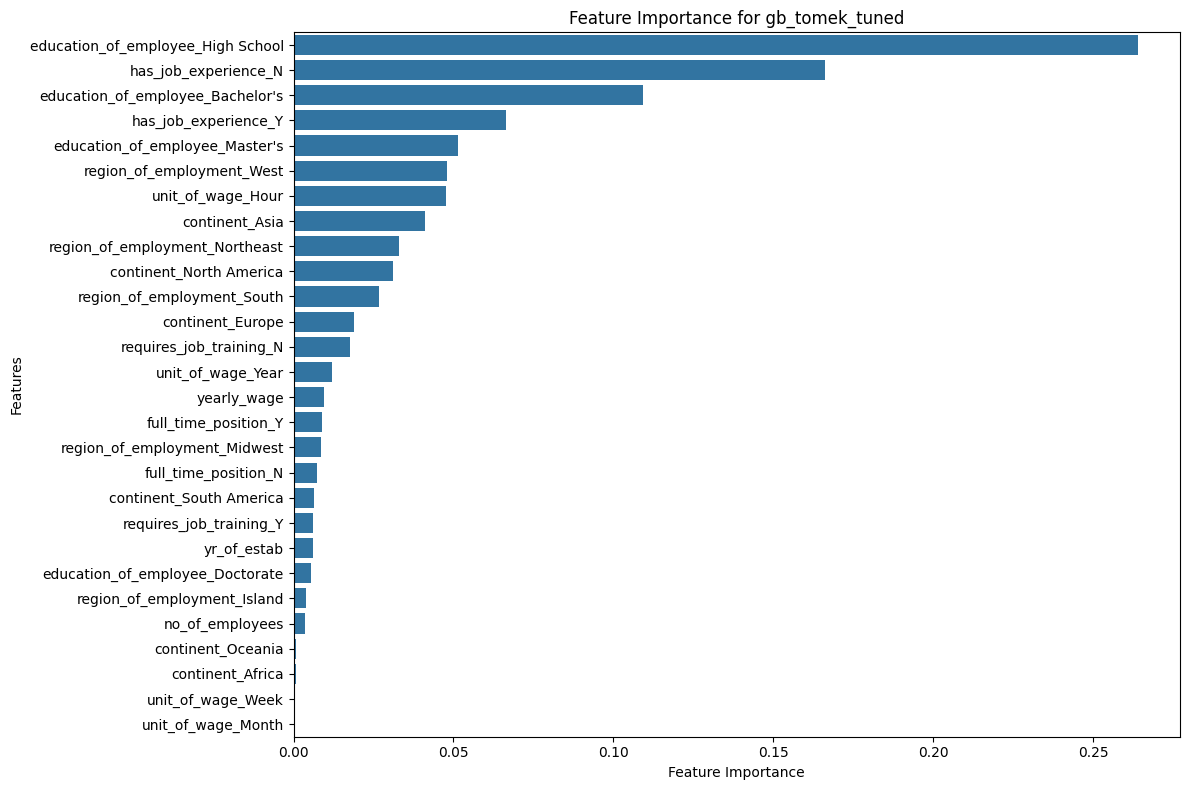

In [ ]:
# Get feature importances for our chosen model
feature_importances = chosen_model.feature_importances_

# Create a Series with feature names and their importances
feature_importance_series = pd.Series(feature_importances, index=X_train.columns)

# Sort the features by importance in descending order
feature_importance_series = feature_importance_series.sort_values(ascending=False)

# Visualize features with importances
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance_series.values, y=feature_importance_series.index)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance for gb_tomek_tuned')
plt.tight_layout()
plt.show()

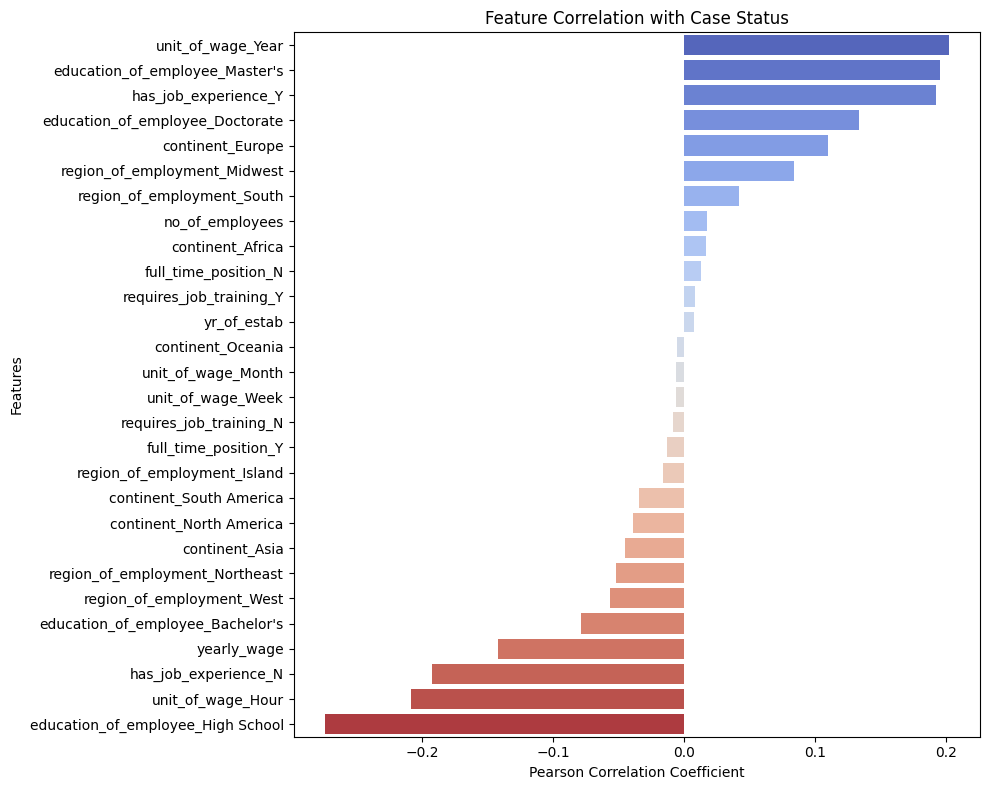

In [ ]:
# Calculate correlations with the target variable 'case_status'
# So that we can account for positive or negative correlations
X_for_corr = df.drop(columns=['case_status'], errors='ignore') # drop the prevailing_wage column because we have the yearly_wage column
y_for_corr = df['case_status']

# Concatenate for correlation calculation (as all are numerical/boolean now)
correlation_df = pd.concat([X_for_corr, y_for_corr], axis=1)
correlations = correlation_df.corr()['case_status'].drop('case_status') # Exclude self-correlation

# Sort correlations
sorted_correlations = correlations.sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x=sorted_correlations.values, y=sorted_correlations.index, palette='coolwarm')
plt.title('Feature Correlation with Case Status')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Explaining my Chosen Model - Analysis

* Here, according to our chosen model, having a higher completed education made a huge impact on getting certified or denied, with a highest education of high school making an applicant much less likely to get certified and a highest education of Bachelor's making an applicant significantly less likely to get certified. Similarly, having a highest education of Master's or Doctorate made a candidate much more likely to get certified.
> These results make sense contextually. Also, our Bivariate Analysis section said that around 87.2% of Doctorates, 78.6% of Masters, 62.2% of Bachelors, and 34.0% of High School-only applications were approved; the fact that our model places a higher importance on Master's applicants could be due to having many more Master's applicants than Doctorate applicants in our data.

* One more very important feature for our chosen model was job experience, where having job experience would make a candidate much more likely to get certified and not having job experience would make a candidate much less likely to get certified.
> Our Bivariate Analysis Summary section backs this up, saying that 74.5% of those with job experience got certified versus 56.1% of those without job experience.

* The continent from which an applicant was applying also made a significant difference for our model. According to our chosen model, applicants from Europe were much more likely to get accepted, applicants from Africa were slightly more likely to get accepted, applicants from Oceania were very slightly less likely to get certified, applicants from South America and North America were somewhat less likely to get accepted, and applicants from Asia were noticeably less likely to get accepted.
>Our Bivariate analysis section states that 79.2% of visas from Europe, 72.1% from Africa, 65.3% from Asia, 63.5% from Oceania, 61.9% from North America, and 57.9% from South America were approved. This backs up most of our model, except for two key differences; the first is that, from the Bivariate Analysis results, applicants from Asia were more likely to get certified than applicants from Oceania, North America, and South America, and thus Asia's feature importance should be less negative than those for other continents or even positive. The second difference is that, again from Bivariate Analysis results, the negative importance of South America should be notably stronger than for North America, whereas our model places North America with slightly stronger negative importance than South America.


* This model has a very high positive importance for unit of wage being yearly, a slightly negative importance for unit of wage being monthly or weekly, and a very negative importance for unit of wage being hourly. Our Bivariate Analysis section supports all these findings, but it is also important to note that we had very few monthly and significantly few weekly samples to train our model on.
> According to our Bivariate analysis, those with a unit of wage in hours were unlikely to be certified (34.6%), compared to those with a weekly wage (62.1%), montly wage (61.8%), or yearly wage (69.9%). This supports our chosen model's feature importances, but based on the certification rate for continent=Europe (79.2%) being much higher than that for unit_of_wage=Yearly, it is surprising that our model places unit_of_wage=Yearly at a much higher importance than continent=Europe.

* The region of employment also had a big role in our model. The model placed a very strong positive importance on region_of_employment=Midwest and a noticeable positive importance on the South region, along with negative importances on the Island, Northeast, and West regions.
> Our Bivariate analysis backs up the results on the Midwest and South. However, In our data, the Island region approved approximately 60.3% of visas, the Midwest region approximately 75.5%, the Northeast region approximately 62.9%, the South approximately 70.0%, and the West region approximately 62.2%, meaning that the importance for Island should be stronger negatively than those of Northeast and West.

* Our model also did not place much importance on a position being full-time or part-time, and our bivariate analysis backs this up by saying that the difference in certification rates for these two categories is not very high and that the certification rates for these categories are both close to the certification rate of the overall data.

* Our model places a noticeable importance on no_of_employees.
> It is possible that this is truly reflective of the data, but it is hard to tell in this case because there are lots of extremely high values and this is a numerical column rather than a categorical column. To improve on this, we could have visualized the correlation for no_of_employees versus case_status after encoding case_status with 0 for Denied or 1 for Certified.

* The year of establishment had very little importance in this model, and our Bivariate Analysis supports this conclusion for our data.


Our model has around a 74.4% accuracy on predicting whether a visa will be certified or not. The thing is that it has a very high recall (around 86.1%), meaning that most of the candidates who should be certified will be certified. The precision is around 77.5%, meaning that around 77.5% of our positive predictions should actually be correct.

The main issue with our model (as seen in our confusion matrix) is lots of false positives, IE our model will certify lots of people who would not otherwise be certified. This is likely due in part to having most of our samples in our data being certified, but might indicate something else as our attempts to balance classes (in our chosen model, we used SMOTE to oversample IE add synthetic samples of the minority class) did not reduce this much.

## Improvements

One thing I could do to improve the model is to display the results of the model on each categorical variable, such as continent = North America (IE continent_North_America == True) or other values, and likewise with unit_of_wage, continent, region_of_employment, and all the other categorical variables. That way, we could see if these feature importances from our chosen model are really reflective of the actual data or if our model has some issues on certain category values

I could also try more oversampling or undersampling techniques to reduce the false positives; if we could significantly reduce the false positives, our model accuracy would be much higher

___